# Análisis Estadístico Completo de Características del Mercado Inmobiliario

**Proyecto:** Forecasting del Mercado Inmobiliario en Ciudades Españolas con Big Data  
**Propósito:** Análisis univariante, multivariante y covariante de las características de los datasets  
**Dataset:** Datos finales procesados de 20 provincias españolas  
**Fecha:** 2025-09-23  
**Entorno requerido:** Python 3.9+, pandas, numpy, scipy, scikit-learn, matplotlib, seaborn  

## Objetivos del Análisis

1. **Análisis Univariante**: Distribuciones, estadísticas descriptivas, detección de outliers
2. **Análisis Multivariante**: Correlaciones, PCA, análisis de variables categóricas
3. **Análisis Covariante**: Relaciones entre variables, matrices de covarianza, análisis de dependencias

## Estructura de Datos

Variables disponibles:
- `price`: Precio (variable objetivo)
- `bath_num`: Número de baños (numérica)
- `room_num`: Número de habitaciones (numérica)  
- `house_type`: Tipo de vivienda (categórica)
- `m2_real`: Metros cuadrados reales (numérica)
- `m2_useful`: Metros cuadrados útiles (numérica)
- `construct_date`: Año de construcción (numérica)
- `garage`: Tiene garaje (binaria)
- `garden`: Tiene jardín (binaria)
- `air_conditioner`: Tiene aire acondicionado (binaria)
- `balcony`: Tiene balcón (binaria)
- `swimming_pool`: Tiene piscina (binaria)
- `terrace`: Tiene terraza (binaria)
- `lift`: Tiene ascensor (binaria)
- `energetic_certif`: Certificación energética (categórica)
- `floor`: Planta (categórica)
- `loc_city`: Ciudad (categórica)
- `loc_zone`: Zona/comarca (categórica)


In [13]:
# Imports y configuración inicial
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
from typing import List, Dict, Tuple, Optional

# Estadísticas y análisis
from scipy import stats
from scipy.stats import (
    normaltest, shapiro, jarque_bera, anderson,
    pearsonr, spearmanr, kendalltau
)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_regression

# Configuración
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Configuración de figuras
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Reproducibilidad
np.random.seed(42)

print("✅ Librerías importadas correctamente")
print(f"📊 Pandas version: {pd.__version__}")
print(f"🔢 Numpy version: {np.__version__}")
print(f"📈 Matplotlib version: {plt.matplotlib.__version__}")
print(f"🎨 Seaborn version: {sns.__version__}")


✅ Librerías importadas correctamente
📊 Pandas version: 2.2.3
🔢 Numpy version: 2.3.3
📈 Matplotlib version: 3.10.1
🎨 Seaborn version: 0.13.2


In [14]:
# Funciones de utilidad para carga y preprocesamiento de datos

def load_all_datasets(data_path: str = "../data/final") -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Carga todos los datasets de ventas y alquileres.
    
    Returns:
        Tuple[pd.DataFrame, pd.DataFrame]: (sales_data, rental_data)
    """
    data_path = Path(data_path)
    
    sales_data = []
    rental_data = []
    
    # Lista de provincias disponibles
    provinces = [
        'alava', 'albacete', 'alicante', 'balears', 'barcelona', 'bizkaia',
        'cadiz', 'ciudad_real', 'coruna', 'gipuzkoa', 'girona', 'huelva',
        'madrid', 'santa_cruz_de_tenerife', 'segovia', 'sevilla', 'soria',
        'valencia', 'valladolid', 'zamora'
    ]
    
    for province in provinces:
        province_path = data_path / province
        
        # Cargar datos de ventas
        sales_file = province_path / f"{province}_sales_final.csv"
        if sales_file.exists():
            df_sales = pd.read_csv(sales_file)
            df_sales['province'] = province
            df_sales['market_type'] = 'sales'
            sales_data.append(df_sales)
            print(f"✅ Cargado {province} - Sales: {len(df_sales)} registros")
        
        # Cargar datos de alquileres
        rental_file = province_path / f"{province}_rental_final.csv"
        if rental_file.exists():
            df_rental = pd.read_csv(rental_file)
            df_rental['province'] = province
            df_rental['market_type'] = 'rental'
            rental_data.append(df_rental)
            print(f"✅ Cargado {province} - Rental: {len(df_rental)} registros")
    
    # Concatenar todos los datasets
    all_sales = pd.concat(sales_data, ignore_index=True) if sales_data else pd.DataFrame()
    all_rental = pd.concat(rental_data, ignore_index=True) if rental_data else pd.DataFrame()
    
    print(f"\n📊 Resumen de carga:")
    print(f"   Sales total: {len(all_sales):,} registros")
    print(f"   Rental total: {len(all_rental):,} registros")
    
    return all_sales, all_rental


def clean_missing_values(df: pd.DataFrame, threshold: float = 0.6) -> pd.DataFrame:
    """
    Elimina columnas con más del threshold% de valores nulos.
    
    Args:
        df: DataFrame a limpiar
        threshold: Umbral de valores nulos (0.6 = 60%)
        
    Returns:
        pd.DataFrame: DataFrame sin columnas con exceso de nulos
    """
    missing_percentage = df.isnull().sum() / len(df)
    columns_to_drop = missing_percentage[missing_percentage > threshold].index.tolist()
    
    if columns_to_drop:
        print(f"🗑️  Eliminando {len(columns_to_drop)} columnas con >{threshold*100}% valores nulos:")
        for col in columns_to_drop:
            pct = missing_percentage[col] * 100
            print(f"   - {col}: {pct:.1f}% nulos")
        
        df_clean = df.drop(columns=columns_to_drop)
    else:
        df_clean = df.copy()
        print(f"✅ Ninguna columna tiene >{threshold*100}% valores nulos")
    
    return df_clean

def remove_outliers_iqr(df: pd.DataFrame, columns: List[str]) -> pd.DataFrame:
    """
    Elimina outliers usando el método IQR para variables especificadas.
    
    Args:
        df: DataFrame a limpiar
        columns: Lista de columnas para aplicar remoción de outliers
        
    Returns:
        pd.DataFrame: DataFrame sin outliers
    """
    df_clean = df.copy()
    initial_count = len(df_clean)
    outliers_removed = {}
    
    for col in columns:
        if col not in df_clean.columns:
            continue
            
        # Solo aplicar a columnas numéricas con datos válidos
        if df_clean[col].dtype in ['float64', 'int64'] and df_clean[col].notna().sum() > 0:
            data = df_clean[col].dropna()
            
            if len(data) > 0:
                Q1 = data.quantile(0.25)
                Q3 = data.quantile(0.75)
                IQR = Q3 - Q1
                lower_bound = Q1 - 1.5 * IQR
                upper_bound = Q3 + 1.5 * IQR
                
                # Contar outliers antes de eliminar
                outliers_mask = (df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)
                outliers_count = outliers_mask.sum()
                
                if outliers_count > 0:
                    # Eliminar outliers
                    df_clean = df_clean[~outliers_mask | df_clean[col].isna()]
                    outliers_removed[col] = outliers_count
    
    final_count = len(df_clean)
    total_removed = initial_count - final_count
    
    if outliers_removed:
        print(f"🚫 Outliers eliminados por columna (método IQR):")
        for col, count in outliers_removed.items():
            pct = (count / initial_count) * 100
            print(f"   - {col}: {count:,} outliers ({pct:.1f}%)")
        print(f"📊 Total registros eliminados: {total_removed:,} ({(total_removed/initial_count)*100:.1f}%)")
    else:
        print("✅ No se encontraron outliers significativos")
    
    return df_clean

def preprocess_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Preprocesa los datos para análisis estadístico con limpieza estricta.
    
    Args:
        df: DataFrame a preprocesar
        
    Returns:
        pd.DataFrame: DataFrame preprocesado y limpio
    """
    print(f"📊 Iniciando preprocesamiento con {len(df):,} registros")
    
    # 1. Eliminar columnas con exceso de valores nulos
    df_clean = clean_missing_values(df, threshold=0.6)
    
    # 2. Convertir tipos de datos
    numeric_cols = ['price', 'bath_num', 'room_num', 'm2_real', 'm2_useful', 'construct_date']
    binary_cols = ['garage', 'garden', 'air_conditioner', 'balcony', 'built_in_wardrobe', 
                   'chimney', 'lift', 'reduced_mobility', 'storage_room', 'swimming_pool', 'terrace']
    
    for col in numeric_cols:
        if col in df_clean.columns:
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
    
    # Convertir variables binarias a numéricas (0/1)
    for col in binary_cols:
        if col in df_clean.columns:
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
    
    # 3. Crear variables derivadas (antes de eliminar outliers)
    if 'm2_real' in df_clean.columns and 'price' in df_clean.columns:
        df_clean['price_per_m2'] = df_clean['price'] / df_clean['m2_real']
        df_clean['price_per_m2'] = df_clean['price_per_m2'].replace([np.inf, -np.inf], np.nan)
    
    if 'construct_date' in df_clean.columns:
        current_year = 2025
        df_clean['property_age'] = current_year - df_clean['construct_date']
        df_clean['property_age'] = df_clean['property_age'].clip(lower=0)
    
    # Crear variable de densidad de habitaciones
    if 'm2_real' in df_clean.columns and 'room_num' in df_clean.columns:
        df_clean['room_density'] = df_clean['room_num'] / df_clean['m2_real']
        df_clean['room_density'] = df_clean['room_density'].replace([np.inf, -np.inf], np.nan)
    
    # Crear índice de lujo/comodidades
    luxury_features = ['garage', 'garden', 'air_conditioner', 'swimming_pool', 'terrace']
    available_luxury_features = [col for col in luxury_features if col in df_clean.columns]
    if available_luxury_features:
        df_clean['luxury_score'] = df_clean[available_luxury_features].sum(axis=1)
    
    # Crear índice de accesibilidad
    accessibility_features = ['lift', 'reduced_mobility']
    available_accessibility_features = [col for col in accessibility_features if col in df_clean.columns]
    if available_accessibility_features:
        df_clean['accessibility_score'] = df_clean[available_accessibility_features].sum(axis=1)
    
    # Crear variable de eficiencia de espacio (útil vs real)
    if 'm2_real' in df_clean.columns and 'm2_useful' in df_clean.columns:
        df_clean['space_efficiency'] = df_clean['m2_useful'] / df_clean['m2_real']
        df_clean['space_efficiency'] = df_clean['space_efficiency'].replace([np.inf, -np.inf], np.nan)
    
    # 4. Eliminar outliers usando método IQR
    outlier_columns = ['price', 'bath_num', 'room_num', 'm2_real', 'm2_useful', 
                       'price_per_m2', 'property_age', 'room_density']
    
    # Solo incluir columnas que existen en el DataFrame
    outlier_columns = [col for col in outlier_columns if col in df_clean.columns]
    
    df_clean = remove_outliers_iqr(df_clean, outlier_columns)
    
    print(f"✅ Preprocesamiento completado: {len(df_clean):,} registros finales")
    print(f"📉 Reducción total: {len(df) - len(df_clean):,} registros ({((len(df) - len(df_clean))/len(df))*100:.1f}%)")
    
    return df_clean

# Cargar y preprocesar datos
print("🔄 Cargando datasets...")
sales_data, rental_data = load_all_datasets()

print("\n🔧 Preprocesando datos...")
sales_clean = preprocess_data(sales_data)
rental_clean = preprocess_data(rental_data)


🔄 Cargando datasets...
✅ Cargado alava - Sales: 3679 registros
✅ Cargado alava - Rental: 127 registros
✅ Cargado albacete - Sales: 4469 registros
✅ Cargado albacete - Rental: 0 registros
✅ Cargado alicante - Sales: 1946 registros
✅ Cargado alicante - Rental: 0 registros
✅ Cargado balears - Sales: 24880 registros
✅ Cargado balears - Rental: 0 registros
✅ Cargado barcelona - Sales: 885 registros
✅ Cargado barcelona - Rental: 0 registros
✅ Cargado bizkaia - Sales: 21637 registros
✅ Cargado bizkaia - Rental: 1560 registros
✅ Cargado cadiz - Sales: 787 registros
✅ Cargado cadiz - Rental: 0 registros
✅ Cargado ciudad_real - Sales: 1819 registros
✅ Cargado ciudad_real - Rental: 0 registros
✅ Cargado coruna - Sales: 8341 registros
✅ Cargado coruna - Rental: 0 registros
✅ Cargado gipuzkoa - Sales: 7057 registros
✅ Cargado gipuzkoa - Rental: 648 registros
✅ Cargado girona - Sales: 1811 registros
✅ Cargado girona - Rental: 0 registros
✅ Cargado huelva - Sales: 658 registros
✅ Cargado huelva - Ren

# 1. Análisis Univariante

El análisis univariante examina cada variable de forma individual para entender:
- Distribuciones y estadísticas descriptivas
- Normalidad de las distribuciones
- Calidad de datos post-limpieza
- Patrones y tendencias por variable

## 1.1 Estadísticas Descriptivas Generales


In [15]:
# Análisis descriptivo básico

def descriptive_statistics_summary(df: pd.DataFrame, market_type: str) -> pd.DataFrame:
    """
    Genera estadísticas descriptivas completas para variables numéricas.
    """
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    numeric_cols = [col for col in numeric_cols if col != 'house_id']  # Excluir ID
    
    stats_list = []
    
    for col in numeric_cols:
        if df[col].notna().sum() > 0:  # Solo si hay datos válidos
            col_data = df[col].dropna()
            
            stats_dict = {
                'Variable': col,
                'Market': market_type,
                'Count': len(col_data),
                'Missing': df[col].isna().sum(),
                'Missing_%': (df[col].isna().sum() / len(df)) * 100,
                'Mean': col_data.mean(),
                'Median': col_data.median(),
                'Mode': col_data.mode().iloc[0] if not col_data.mode().empty else np.nan,
                'Std': col_data.std(),
                'Variance': col_data.var(),
                'Min': col_data.min(),
                'Q1': col_data.quantile(0.25),
                'Q3': col_data.quantile(0.75),
                'Max': col_data.max(),
                'Range': col_data.max() - col_data.min(),
                'IQR': col_data.quantile(0.75) - col_data.quantile(0.25),
                'Skewness': col_data.skew(),
                'Kurtosis': col_data.kurtosis(),
                'CV': (col_data.std() / col_data.mean()) * 100 if col_data.mean() != 0 else np.nan
            }
            stats_list.append(stats_dict)
    
    return pd.DataFrame(stats_list)

# Generar estadísticas para ambos mercados
print("📊 ESTADÍSTICAS DESCRIPTIVAS GENERALES")
print("=" * 50)

sales_stats = descriptive_statistics_summary(sales_clean, 'Sales')
rental_stats = descriptive_statistics_summary(rental_clean, 'Rental')

# Combinar estadísticas
all_stats = pd.concat([sales_stats, rental_stats], ignore_index=True)

# Mostrar estadísticas principales
display_cols = ['Variable', 'Market', 'Count', 'Missing_%', 'Mean', 'Median', 'Std', 'Min', 'Max', 'Skewness']
print(all_stats[display_cols].round(2))


📊 ESTADÍSTICAS DESCRIPTIVAS GENERALES
               Variable  Market  Count  Missing_%       Mean     Median  \
0                 price   Sales  61840       0.30  205831.79  172000.00   
1              bath_num   Sales  62023       0.00       1.60       2.00   
2              room_num   Sales  62023       0.00       2.78       3.00   
3            house_type   Sales  62023       0.00       2.09       2.00   
4               m2_real   Sales  61840       0.30     105.25      95.00   
5             m2_useful   Sales  40619      34.51      83.87      85.00   
6        construct_date   Sales  33602      45.82    1984.78    1976.00   
7                garage   Sales  28835      53.51       0.32       0.00   
8          price_per_m2   Sales  61840       0.30    2057.19    1935.48   
9          property_age   Sales  33602      45.82      40.46      49.00   
10         room_density   Sales  61840       0.30       0.03       0.03   
11         luxury_score   Sales  62023       0.00       0.15  

In [16]:
# Análisis de normalidad y distribuciones

def test_normality(data: np.array, variable_name: str) -> Dict:
    """
    Realiza múltiples tests de normalidad en una variable.
    """
    clean_data = data[~np.isnan(data)]
    
    if len(clean_data) < 8:
        return {'variable': variable_name, 'sample_size': len(clean_data), 'error': 'Insufficient data'}
    
    results = {'variable': variable_name, 'sample_size': len(clean_data)}
    
    # Shapiro-Wilk test (mejor para n < 5000)
    if len(clean_data) <= 5000:
        try:
            stat, p_value = shapiro(clean_data)
            results['shapiro_stat'] = stat
            results['shapiro_p'] = p_value
            results['shapiro_normal'] = p_value > 0.05
        except:
            results['shapiro_stat'] = np.nan
            results['shapiro_p'] = np.nan
            results['shapiro_normal'] = False
    
    # D'Agostino's normality test
    try:
        stat, p_value = normaltest(clean_data)
        results['dagostino_stat'] = stat
        results['dagostino_p'] = p_value
        results['dagostino_normal'] = p_value > 0.05
    except:
        results['dagostino_stat'] = np.nan
        results['dagostino_p'] = np.nan
        results['dagostino_normal'] = False
    
    # Jarque-Bera test
    try:
        stat, p_value = jarque_bera(clean_data)
        results['jb_stat'] = stat
        results['jb_p'] = p_value
        results['jb_normal'] = p_value > 0.05
    except:
        results['jb_stat'] = np.nan
        results['jb_p'] = np.nan
        results['jb_normal'] = False
    
    # Anderson-Darling test
    try:
        result = anderson(clean_data, dist='norm')
        results['anderson_stat'] = result.statistic
        results['anderson_critical_5%'] = result.critical_values[2]  # 5% level
        results['anderson_normal'] = result.statistic < result.critical_values[2]
    except:
        results['anderson_stat'] = np.nan
        results['anderson_critical_5%'] = np.nan
        results['anderson_normal'] = False
    
    return results

# Realizar tests de normalidad
print("\n🔍 TESTS DE NORMALIDAD")
print("=" * 50)

normality_results = []

# Variables numéricas principales para testing
test_variables = ['price', 'bath_num', 'room_num', 'm2_real', 'm2_useful', 'price_per_m2', 
                  'property_age', 'garage', 'garden', 'swimming_pool', 'luxury_score', 
                  'accessibility_score', 'space_efficiency']

for market_name, df in [('Sales', sales_clean), ('Rental', rental_clean)]:
    for var in test_variables:
        if var in df.columns:
            result = test_normality(df[var].values, f"{market_name}_{var}")
            result['market'] = market_name
            normality_results.append(result)

# Convertir a DataFrame y mostrar resultados
normality_df = pd.DataFrame(normality_results)

# Mostrar resumen de normalidad
print("Resumen de Tests de Normalidad (p-value > 0.05 = normal):")
display_cols = ['variable', 'sample_size', 'shapiro_p', 'dagostino_p', 'jb_p', 'shapiro_normal', 'dagostino_normal', 'jb_normal']
available_cols = [col for col in display_cols if col in normality_df.columns]
print(normality_df[available_cols].round(4))



🔍 TESTS DE NORMALIDAD
Resumen de Tests de Normalidad (p-value > 0.05 = normal):
                      variable  sample_size  shapiro_p  dagostino_p    jb_p  \
0                  Sales_price        61840        NaN       0.0000  0.0000   
1               Sales_bath_num        62023        NaN       0.0000  0.0000   
2               Sales_room_num        62023        NaN       0.0000  0.0000   
3                Sales_m2_real        61840        NaN       0.0000  0.0000   
4              Sales_m2_useful        40619        NaN       0.0000  0.0000   
5           Sales_price_per_m2        61840        NaN       0.0000  0.0000   
6           Sales_property_age        33602        NaN       0.0000  0.0000   
7                 Sales_garage        28835        NaN       0.0000  0.0000   
8           Sales_luxury_score        62023        NaN       0.0000  0.0000   
9       Sales_space_efficiency        40619        NaN       0.0000  0.0000   
10                Rental_price         1576       


📈 VISUALIZACIONES DE DISTRIBUCIONES
Distribuciones para el mercado de VENTAS:


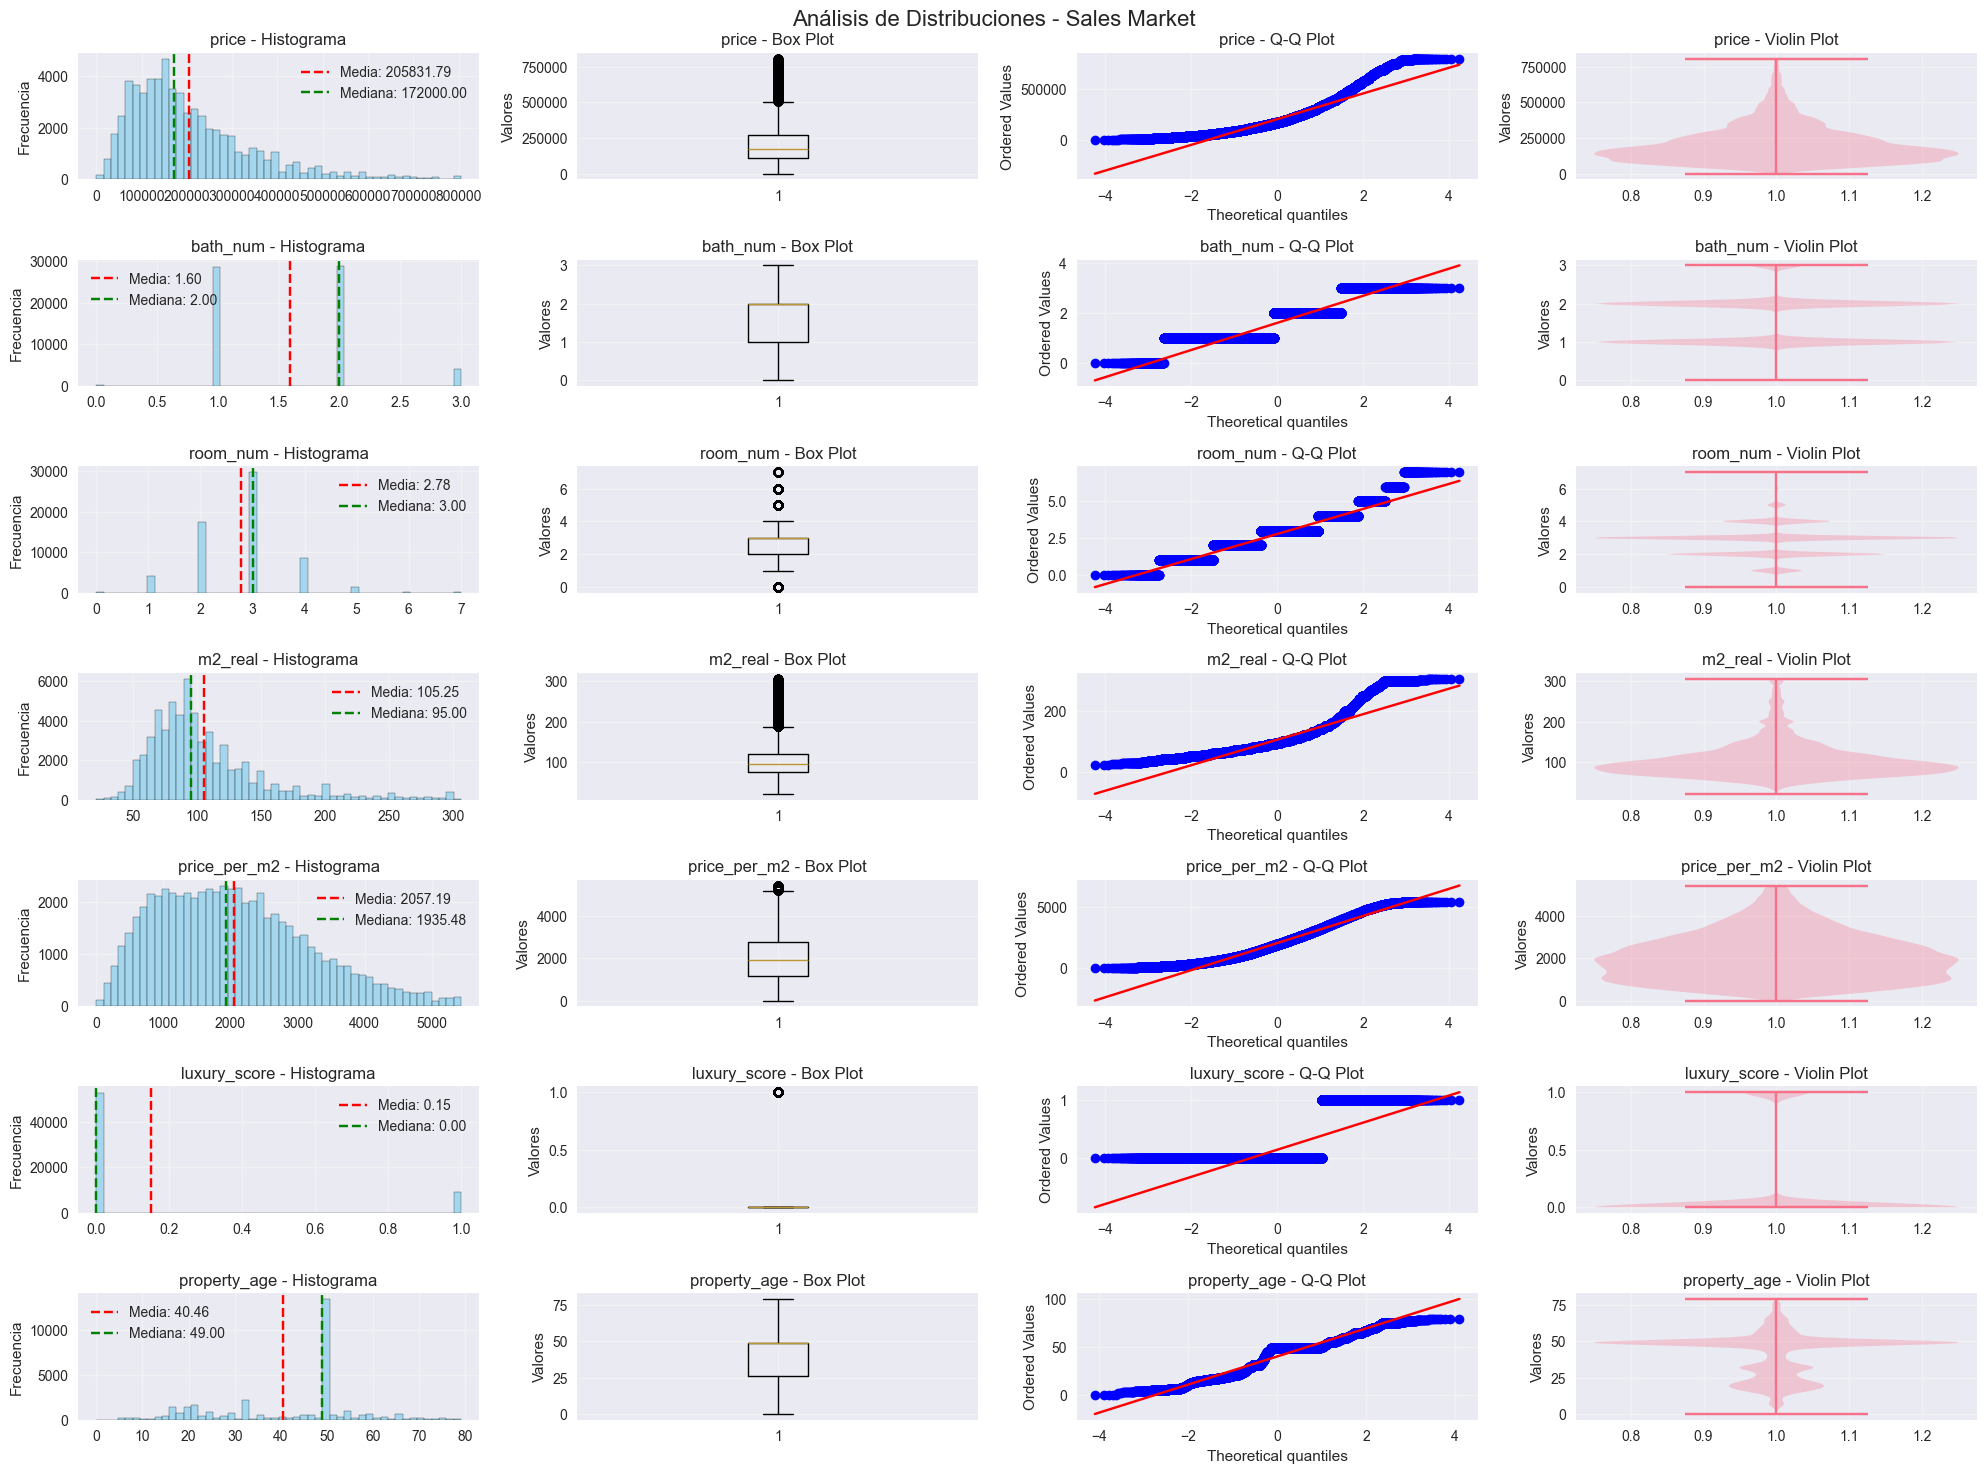


Distribuciones para el mercado de ALQUILERES:


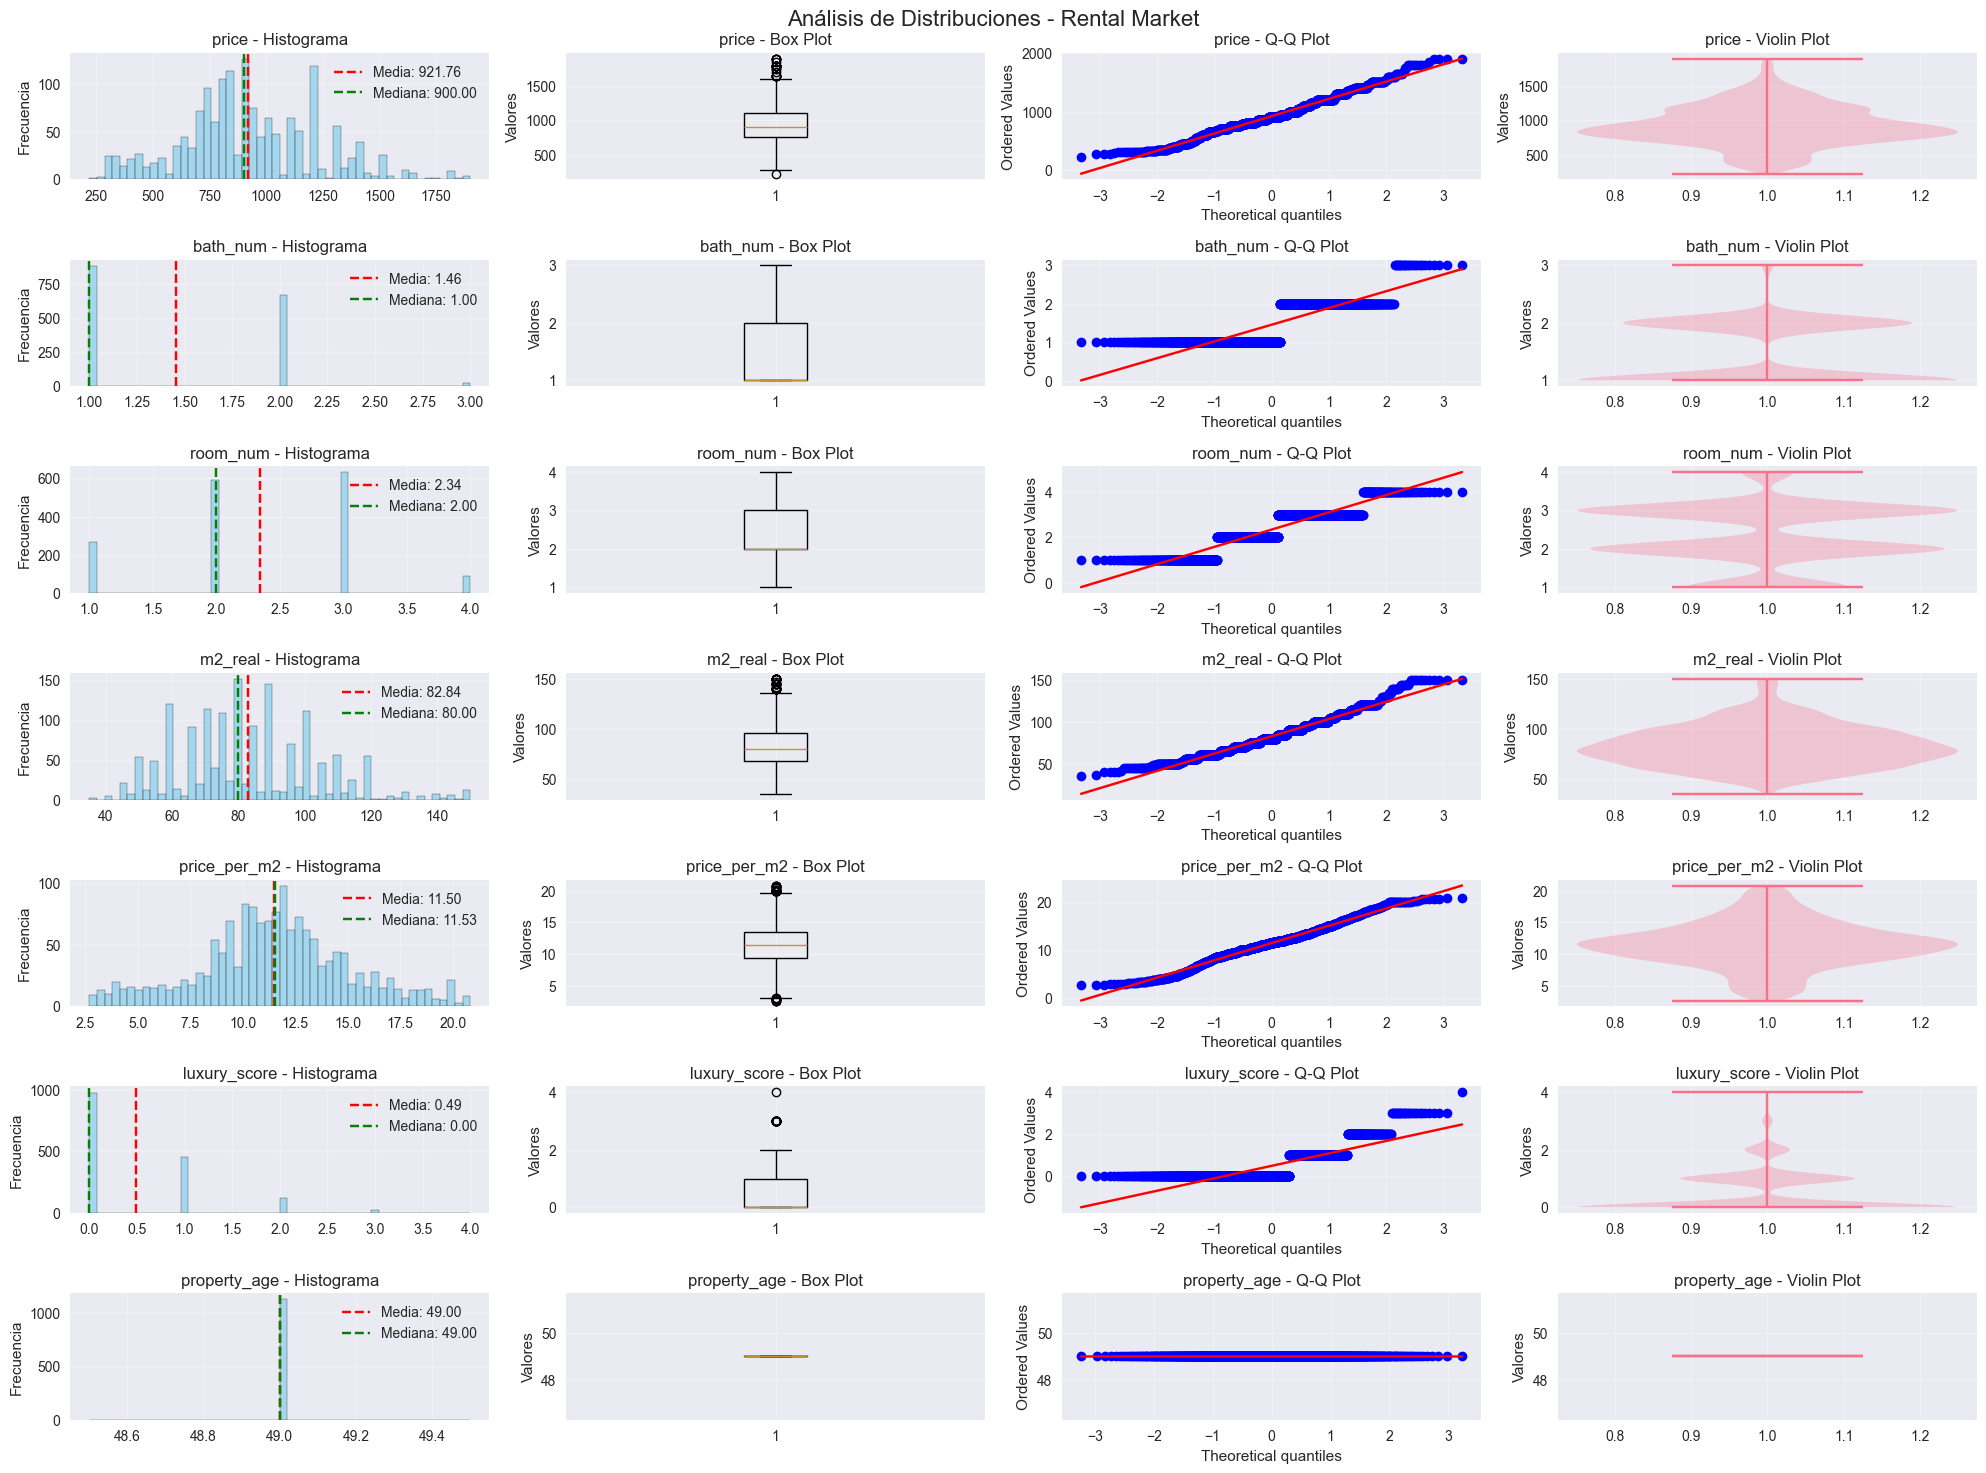

In [17]:
# Visualizaciones de distribuciones univariantes

def plot_distribution_analysis(df: pd.DataFrame, variables: List[str], market_type: str, figsize=(20, 15)):
    """
    Crea gráficos de distribución para análisis univariante.
    """
    n_vars = len(variables)
    fig, axes = plt.subplots(n_vars, 4, figsize=figsize)
    fig.suptitle(f'Análisis de Distribuciones - {market_type}', fontsize=16, y=0.98)
    
    if n_vars == 1:
        axes = axes.reshape(1, -1)
    
    for i, var in enumerate(variables):
        if var not in df.columns:
            continue
            
        data = df[var].dropna()
        
        if len(data) == 0:
            continue
        
        # Histograma
        axes[i, 0].hist(data, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
        axes[i, 0].set_title(f'{var} - Histograma')
        axes[i, 0].set_ylabel('Frecuencia')
        
        # Box plot
        axes[i, 1].boxplot(data, vert=True)
        axes[i, 1].set_title(f'{var} - Box Plot')
        axes[i, 1].set_ylabel('Valores')
        
        # Q-Q plot
        stats.probplot(data, dist="norm", plot=axes[i, 2])
        axes[i, 2].set_title(f'{var} - Q-Q Plot')
        
        # Violin plot
        axes[i, 3].violinplot(data, vert=True)
        axes[i, 3].set_title(f'{var} - Violin Plot')
        axes[i, 3].set_ylabel('Valores')
        
        # Añadir estadísticas al histograma
        mean_val = data.mean()
        median_val = data.median()
        axes[i, 0].axvline(mean_val, color='red', linestyle='--', label=f'Media: {mean_val:.2f}')
        axes[i, 0].axvline(median_val, color='green', linestyle='--', label=f'Mediana: {median_val:.2f}')
        axes[i, 0].legend()
    
    plt.tight_layout()
    plt.show()

# Crear visualizaciones para variables principales
print("\n📈 VISUALIZACIONES DE DISTRIBUCIONES")
print("=" * 50)

main_variables = ['price', 'bath_num', 'room_num', 'm2_real', 'price_per_m2', 'luxury_score', 'property_age']

print("Distribuciones para el mercado de VENTAS:")
plot_distribution_analysis(sales_clean, main_variables, 'Sales Market')

print("\nDistribuciones para el mercado de ALQUILERES:")
plot_distribution_analysis(rental_clean, main_variables, 'Rental Market')


In [18]:
# Análisis de Calidad de Datos Post-Limpieza

def analyze_data_quality(df: pd.DataFrame, market_type: str):
    """
    Analiza la calidad de los datos después de la limpieza.
    """
    print(f"\n📊 ANÁLISIS DE CALIDAD DE DATOS - {market_type}")
    print("=" * 60)
    
    # Resumen general
    print(f"📈 Total de registros: {len(df):,}")
    print(f"📋 Total de columnas: {len(df.columns)}")
    
    # Análisis de valores faltantes por columna
    missing_data = df.isnull().sum()
    missing_percentage = (missing_data / len(df)) * 100
    
    print(f"\n📋 VALORES FALTANTES POR COLUMNA:")
    missing_summary = pd.DataFrame({
        'Column': missing_data.index,
        'Missing_Count': missing_data.values,
        'Missing_Percentage': missing_percentage.values
    })
    
    # Solo mostrar columnas con valores faltantes
    missing_summary = missing_summary[missing_summary['Missing_Count'] > 0]
    
    if len(missing_summary) > 0:
        missing_summary = missing_summary.sort_values('Missing_Percentage', ascending=False)
        print(missing_summary.round(2))
    else:
        print("✅ No hay valores faltantes en ninguna columna")
    
    # Distribución por tipo de datos
    print(f"\n🔍 DISTRIBUCIÓN POR TIPO DE DATOS:")
    dtype_counts = df.dtypes.value_counts()
    for dtype, count in dtype_counts.items():
        print(f"   - {dtype}: {count} columnas")
    
    # Variables numéricas principales
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    numeric_cols = [col for col in numeric_cols if col != 'house_id']
    
    if len(numeric_cols) > 0:
        print(f"\n📊 ESTADÍSTICAS DESCRIPTIVAS BÁSICAS:")
        basic_stats = df[numeric_cols].describe().round(2)
        print(basic_stats)

# Análisis de calidad para ambos mercados
analyze_data_quality(sales_clean, 'MERCADO DE VENTAS')
analyze_data_quality(rental_clean, 'MERCADO DE ALQUILERES')

# Comparar antes y después de la limpieza
print(f"\n📊 RESUMEN DE LIMPIEZA DE DATOS")
print("=" * 50)
print(f"Sales - Registros originales: {len(sales_data):,}")
print(f"Sales - Registros después de limpieza: {len(sales_clean):,}")
print(f"Sales - Reducción: {len(sales_data) - len(sales_clean):,} ({((len(sales_data) - len(sales_clean))/len(sales_data))*100:.1f}%)")
print()
print(f"Rental - Registros originales: {len(rental_data):,}")
print(f"Rental - Registros después de limpieza: {len(rental_clean):,}")
print(f"Rental - Reducción: {len(rental_data) - len(rental_clean):,} ({((len(rental_data) - len(rental_clean))/len(rental_data))*100:.1f}%)")



📊 ANÁLISIS DE CALIDAD DE DATOS - MERCADO DE VENTAS
📈 Total de registros: 62,023
📋 Total de columnas: 18

📋 VALORES FALTANTES POR COLUMNA:
              Column  Missing_Count  Missing_Percentage
10            garage          33188               53.51
9     construct_date          28421               45.82
14      property_age          28421               45.82
6          m2_useful          21404               34.51
17  space_efficiency          21404               34.51
0              price            183                0.30
5            m2_real            183                0.30
13      price_per_m2            183                0.30
15      room_density            183                0.30

🔍 DISTRIBUCIÓN POR TIPO DE DATOS:
   - float64: 12 columnas
   - object: 5 columnas
   - int64: 1 columnas

📊 ESTADÍSTICAS DESCRIPTIVAS BÁSICAS:
           price  bath_num  room_num  house_type   m2_real  m2_useful  \
count   61840.00  62023.00  62023.00    62023.00  61840.00   40619.00   
mean   20

# 2. Análisis Multivariante

El análisis multivariante examina las relaciones entre múltiples variables simultáneamente:
- Matrices de correlación
- Análisis de componentes principales (PCA)
- Análisis de variables categóricas y binarias


## 2.1 Análisis de Correlaciones


🔗 ANÁLISIS DE CORRELACIONES

1. Correlaciones de Pearson:
MERCADO DE VENTAS:


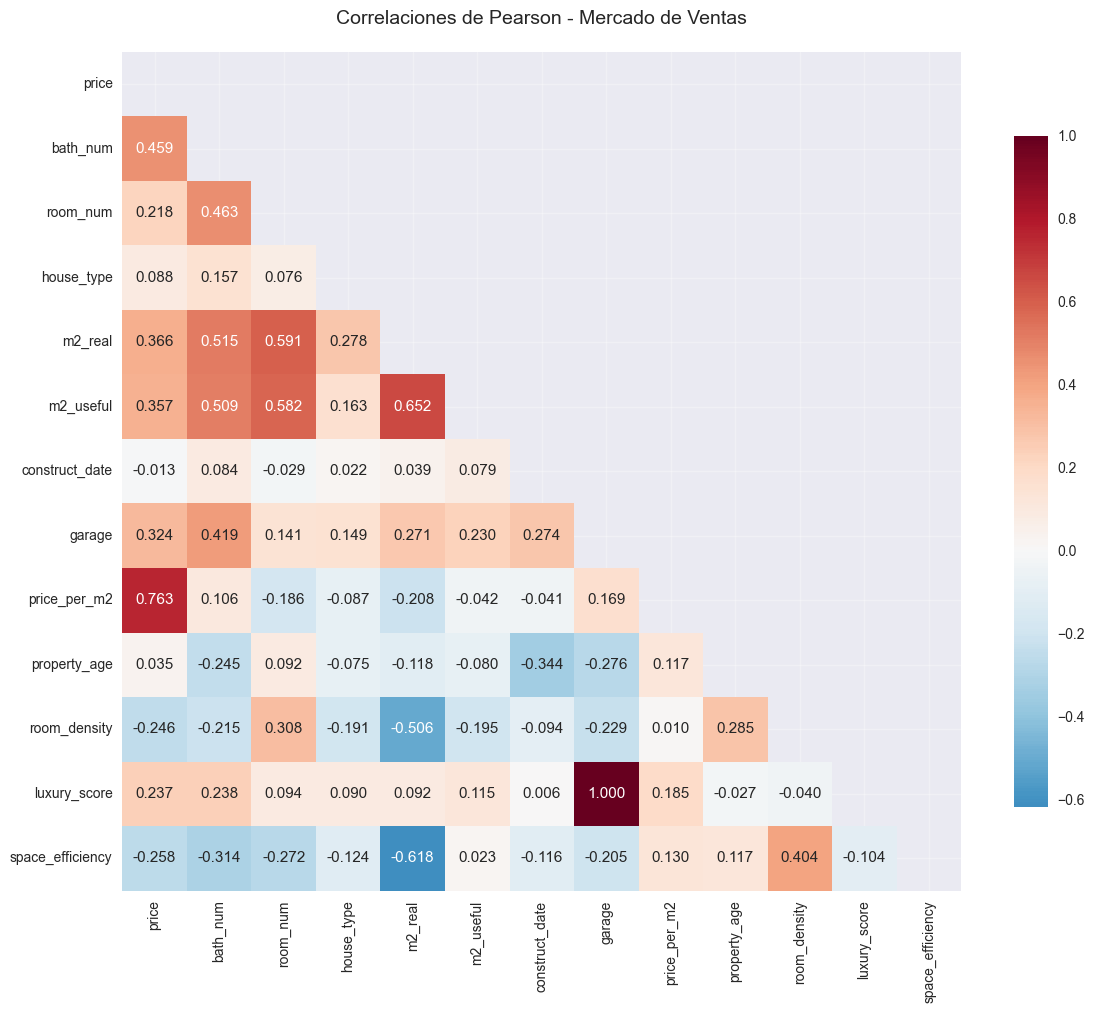

MERCADO DE ALQUILERES:


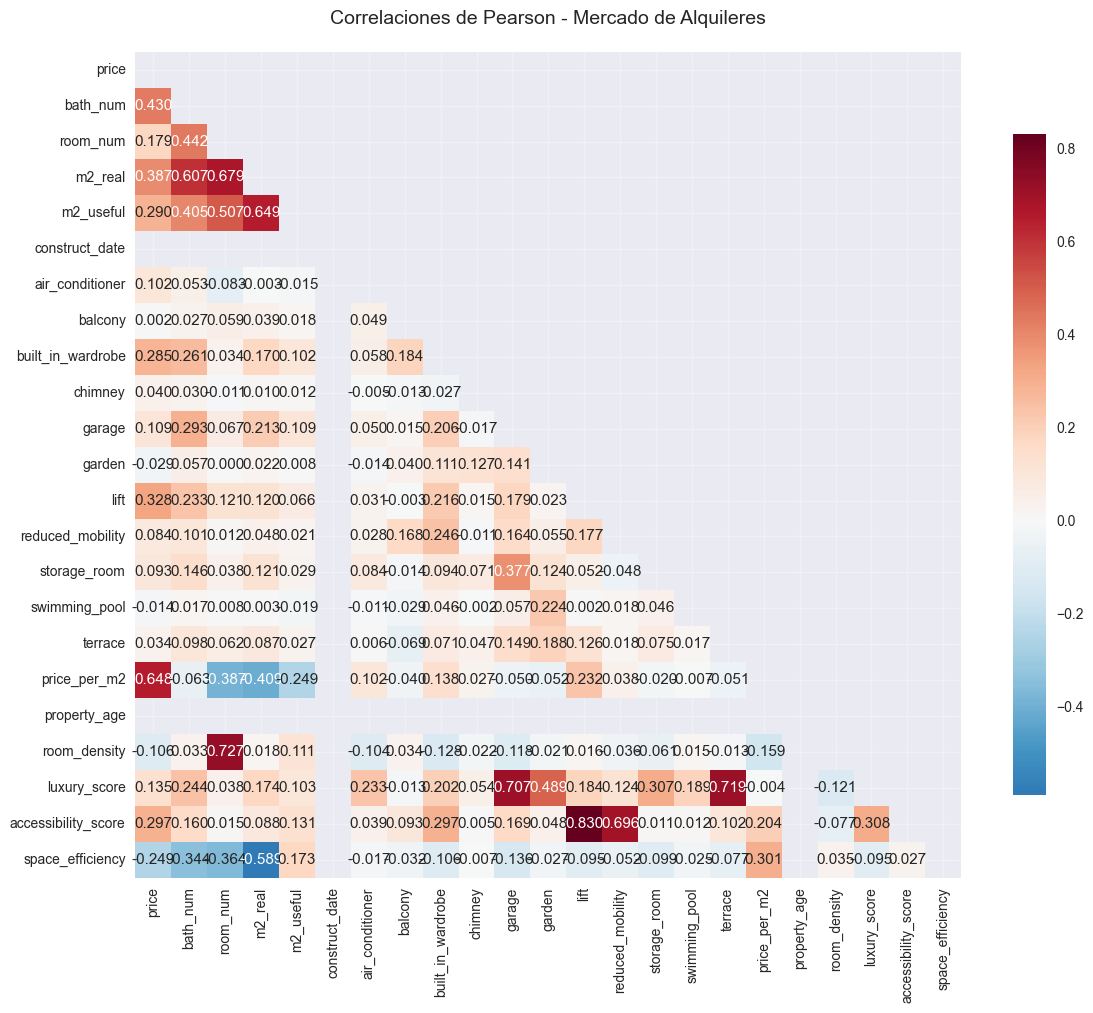


2. Correlaciones de Spearman:
MERCADO DE VENTAS:


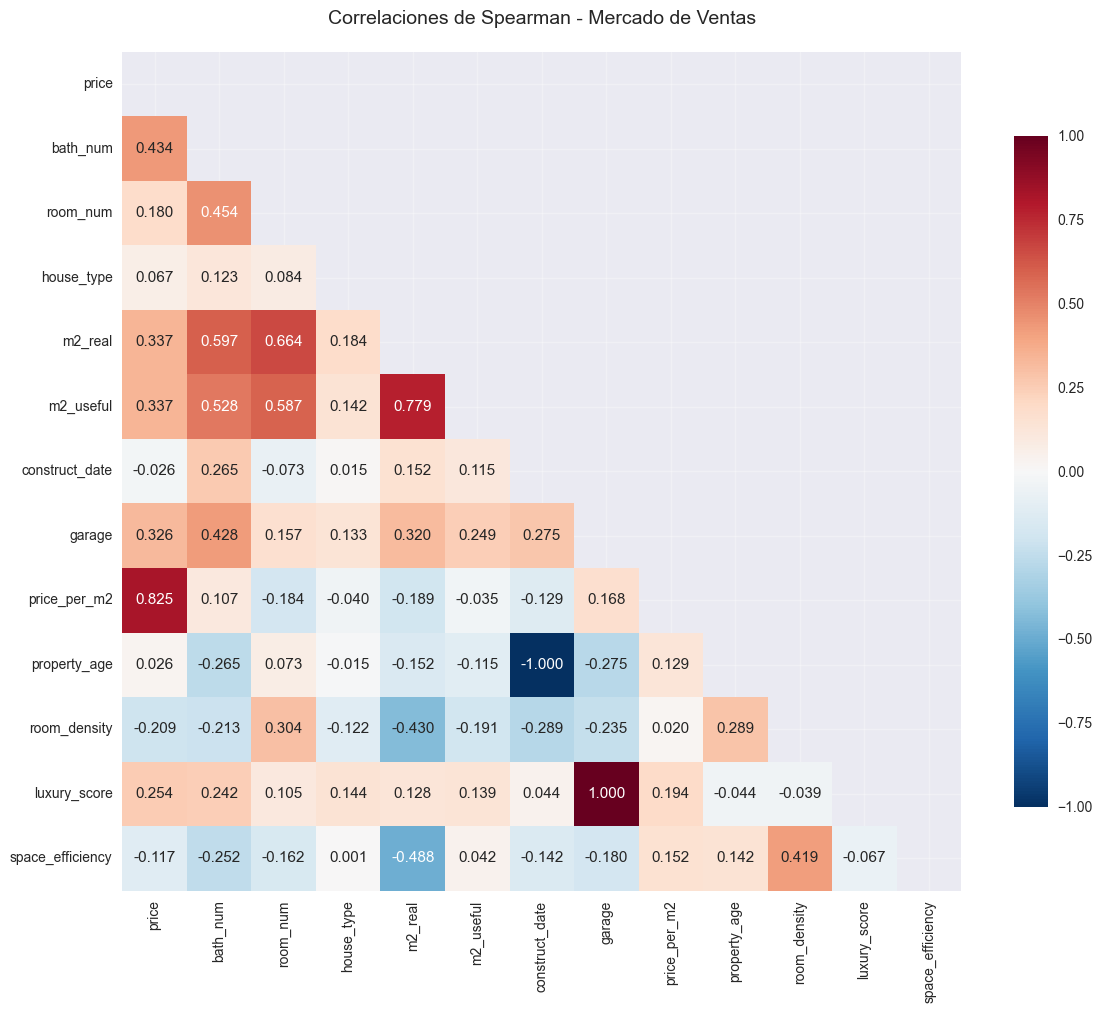

MERCADO DE ALQUILERES:


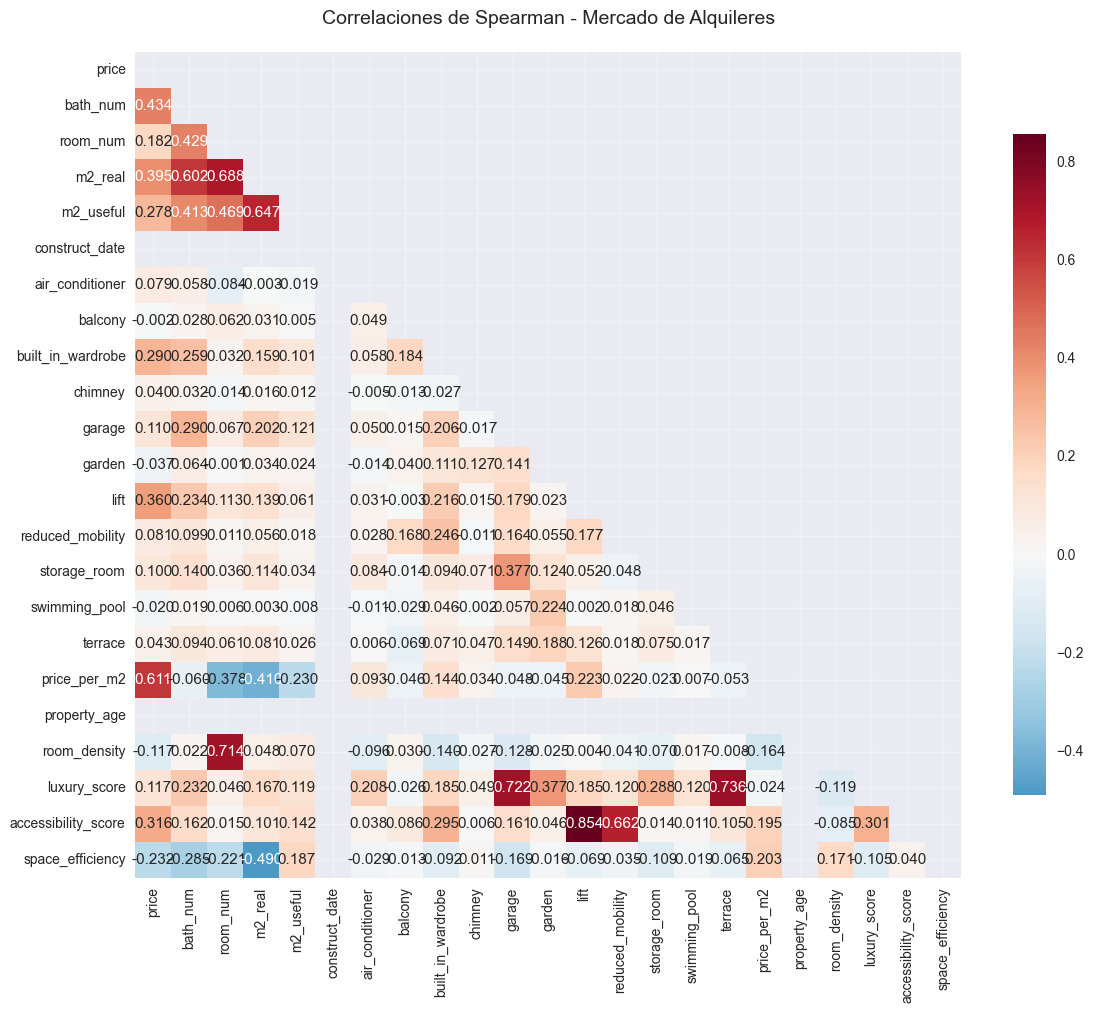

In [19]:
# Análisis de correlaciones

def correlation_analysis(df: pd.DataFrame, method: str = 'pearson') -> Tuple[pd.DataFrame, Dict]:
    """
    Realiza análisis completo de correlaciones.
    
    Args:
        df: DataFrame con variables numéricas
        method: 'pearson', 'spearman', o 'kendall'
    
    Returns:
        Tuple[correlation_matrix, significance_tests]
    """
    # Seleccionar solo variables numéricas
    numeric_df = df.select_dtypes(include=[np.number])
    numeric_df = numeric_df.drop(columns=['house_id'], errors='ignore')
    
    # Calcular matriz de correlación
    corr_matrix = numeric_df.corr(method=method)
    
    # Tests de significancia
    significance_results = {}
    variables = corr_matrix.columns.tolist()
    
    for i, var1 in enumerate(variables):
        for j, var2 in enumerate(variables):
            if i < j:  # Solo calcular para pares únicos
                data1 = numeric_df[var1].dropna()
                data2 = numeric_df[var2].dropna()
                
                # Obtener datos comunes (sin NaN en ninguna variable)
                common_indices = data1.index.intersection(data2.index)
                if len(common_indices) > 3:
                    x = numeric_df.loc[common_indices, var1]
                    y = numeric_df.loc[common_indices, var2]
                    
                    try:
                        if method == 'pearson':
                            corr_coef, p_value = pearsonr(x, y)
                        elif method == 'spearman':
                            corr_coef, p_value = spearmanr(x, y)
                        elif method == 'kendall':
                            corr_coef, p_value = kendalltau(x, y)
                        
                        significance_results[f"{var1}_vs_{var2}"] = {
                            'correlation': corr_coef,
                            'p_value': p_value,
                            'significant': p_value < 0.05,
                            'n_observations': len(x)
                        }
                    except:
                        pass
    
    return corr_matrix, significance_results

def plot_correlation_heatmap(corr_matrix: pd.DataFrame, title: str, figsize=(12, 10)):
    """
    Crea un heatmap de correlación.
    """
    plt.figure(figsize=figsize)
    
    # Crear máscara para la triangular superior
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    # Heatmap
    sns.heatmap(corr_matrix, 
                mask=mask,
                annot=True, 
                cmap='RdBu_r', 
                center=0,
                square=True,
                fmt='.3f',
                cbar_kws={"shrink": .8})
    
    plt.title(title, fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()

# Análisis de correlaciones para ambos mercados
print("🔗 ANÁLISIS DE CORRELACIONES")
print("=" * 50)

# Correlaciones de Pearson
print("\n1. Correlaciones de Pearson:")
sales_corr_pearson, sales_sig_pearson = correlation_analysis(sales_clean, 'pearson')
rental_corr_pearson, rental_sig_pearson = correlation_analysis(rental_clean, 'pearson')

print("MERCADO DE VENTAS:")
plot_correlation_heatmap(sales_corr_pearson, 'Correlaciones de Pearson - Mercado de Ventas')

print("MERCADO DE ALQUILERES:")
plot_correlation_heatmap(rental_corr_pearson, 'Correlaciones de Pearson - Mercado de Alquileres')

# Correlaciones de Spearman
print("\n2. Correlaciones de Spearman:")
sales_corr_spearman, sales_sig_spearman = correlation_analysis(sales_clean, 'spearman')
rental_corr_spearman, rental_sig_spearman = correlation_analysis(rental_clean, 'spearman')

print("MERCADO DE VENTAS:")
plot_correlation_heatmap(sales_corr_spearman, 'Correlaciones de Spearman - Mercado de Ventas')

print("MERCADO DE ALQUILERES:")
plot_correlation_heatmap(rental_corr_spearman, 'Correlaciones de Spearman - Mercado de Alquileres')



🔍 ANÁLISIS DE COMPONENTES PRINCIPALES (PCA)

PCA para MERCADO DE VENTAS:
Varianza total explicada: 1.0000
Varianza explicada por PC1: 0.3454
Varianza explicada por PC2: 0.1691


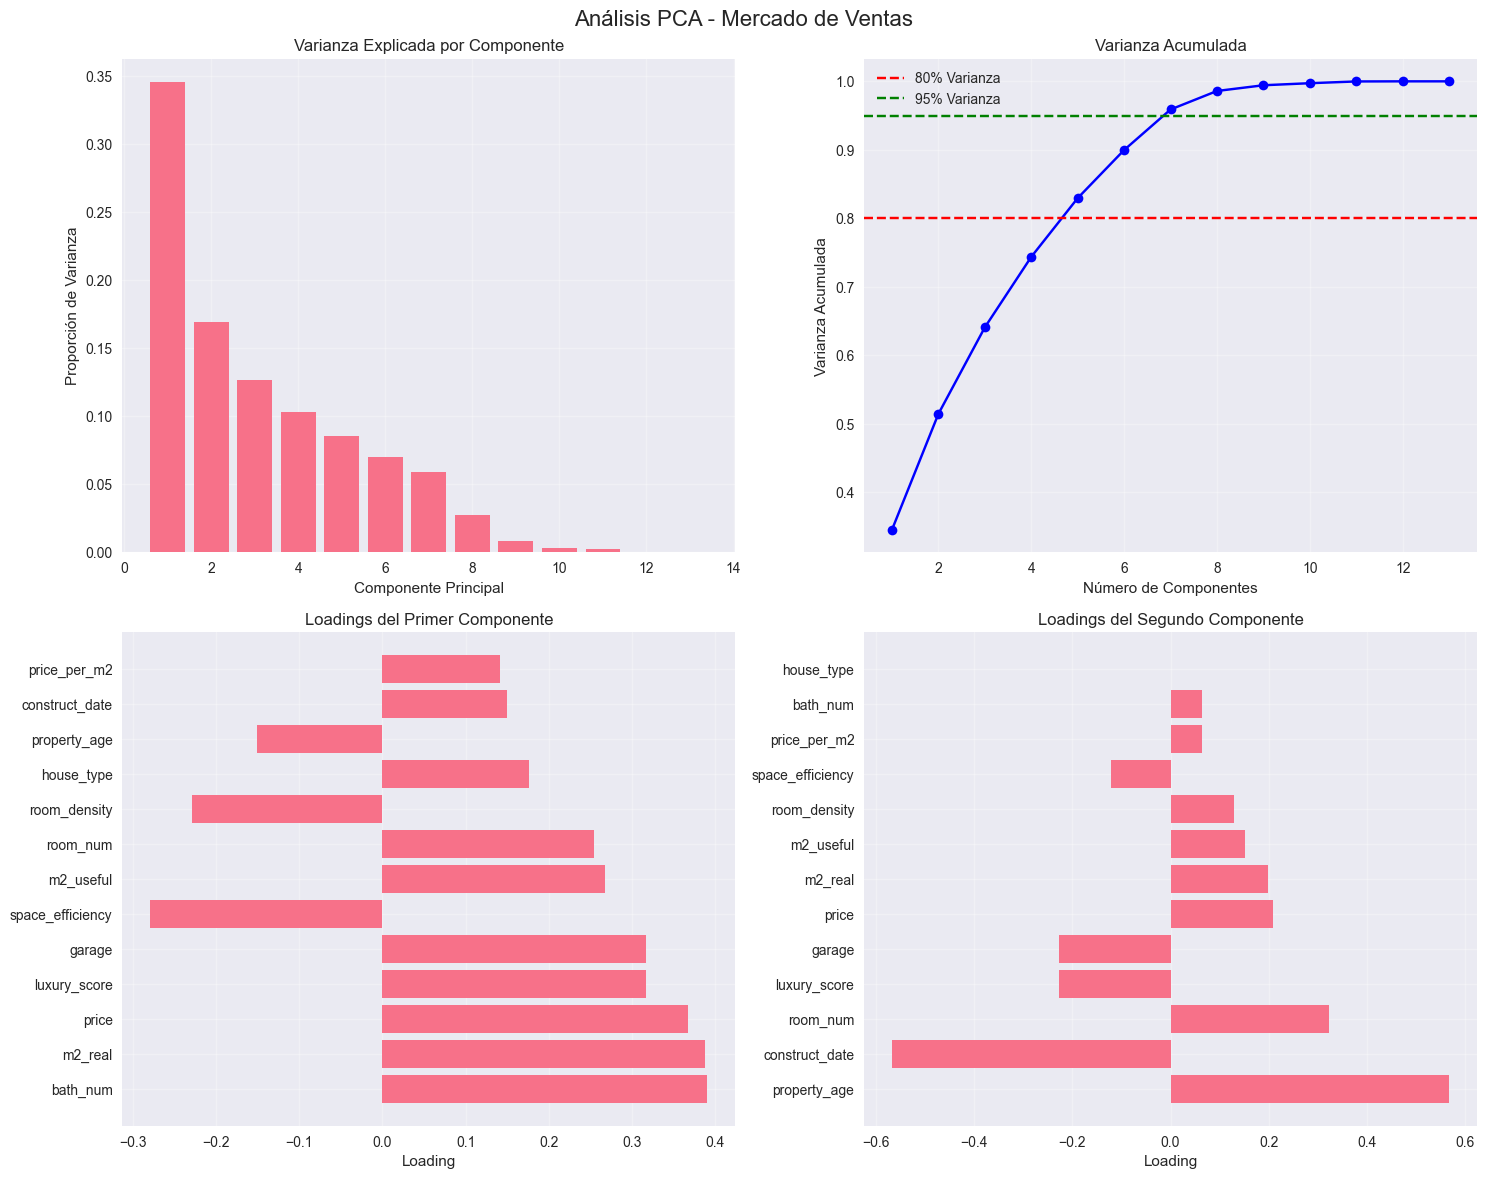


PCA para MERCADO DE ALQUILERES:
Varianza total explicada: 1.0000
Varianza explicada por PC1: 0.1950
Varianza explicada por PC2: 0.1281


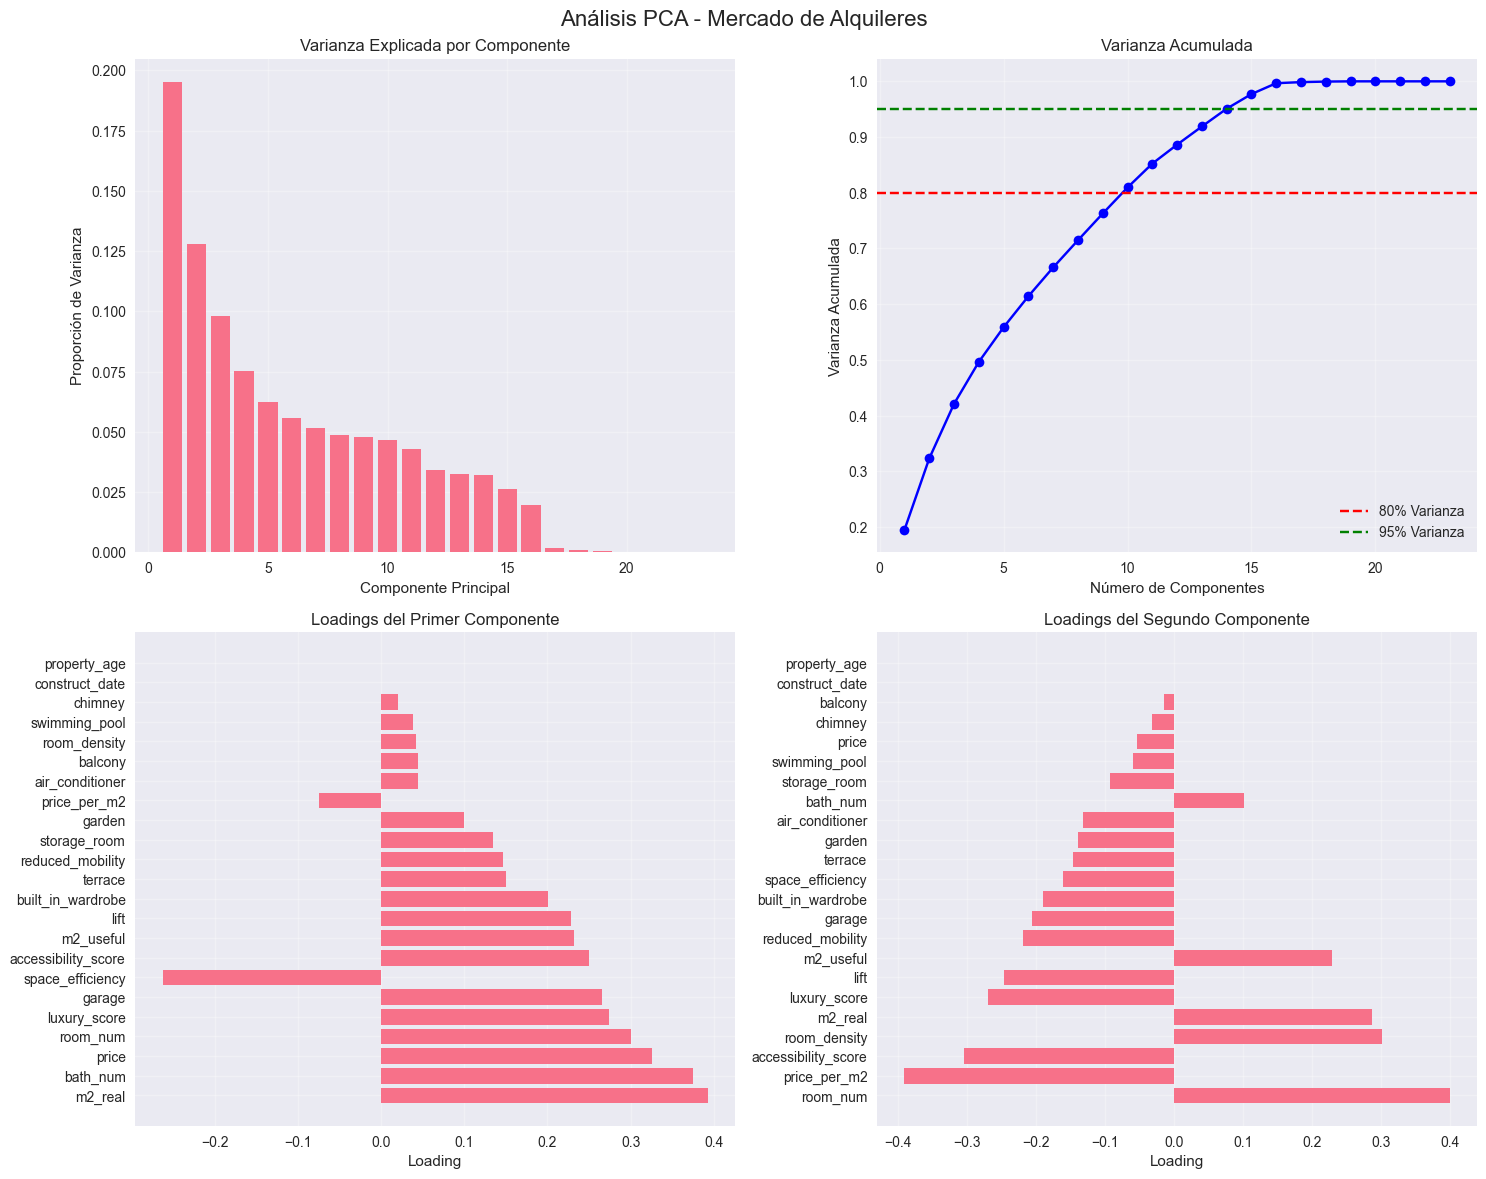

In [20]:
# Análisis de Componentes Principales (PCA)

def perform_pca_analysis(df: pd.DataFrame, market_type: str, n_components: Optional[int] = None):
    """
    Realiza análisis PCA completo.
    """
    # Preparar datos
    numeric_df = df.select_dtypes(include=[np.number])
    numeric_df = numeric_df.drop(columns=['house_id'], errors='ignore')
    
    # Eliminar filas con NaN
    numeric_df_clean = numeric_df.dropna()
    
    if len(numeric_df_clean) == 0:
        print(f"No hay datos válidos para PCA en {market_type}")
        return None, None, None
    
    # Estandarizar datos
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(numeric_df_clean)
    
    # PCA
    if n_components is None:
        n_components = min(len(numeric_df_clean.columns), len(numeric_df_clean))
    
    pca = PCA(n_components=n_components)
    principal_components = pca.fit_transform(scaled_data)
    
    # Crear DataFrame de componentes principales
    pc_columns = [f'PC{i+1}' for i in range(n_components)]
    pca_df = pd.DataFrame(data=principal_components, columns=pc_columns)
    
    # Resultados del análisis
    results = {
        'explained_variance_ratio': pca.explained_variance_ratio_,
        'cumulative_variance_ratio': np.cumsum(pca.explained_variance_ratio_),
        'components': pca.components_,
        'feature_names': numeric_df_clean.columns.tolist(),
        'n_components': n_components,
        'total_variance_explained': np.sum(pca.explained_variance_ratio_)
    }
    
    return pca_df, results, pca

def plot_pca_results(results: Dict, market_type: str):
    """
    Visualiza resultados del PCA.
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle(f'Análisis PCA - {market_type}', fontsize=16)
    
    # 1. Varianza explicada por componente
    axes[0, 0].bar(range(1, len(results['explained_variance_ratio']) + 1), 
                   results['explained_variance_ratio'])
    axes[0, 0].set_title('Varianza Explicada por Componente')
    axes[0, 0].set_xlabel('Componente Principal')
    axes[0, 0].set_ylabel('Proporción de Varianza')
    
    # 2. Varianza acumulada
    axes[0, 1].plot(range(1, len(results['cumulative_variance_ratio']) + 1), 
                    results['cumulative_variance_ratio'], 'bo-')
    axes[0, 1].axhline(y=0.8, color='r', linestyle='--', label='80% Varianza')
    axes[0, 1].axhline(y=0.95, color='g', linestyle='--', label='95% Varianza')
    axes[0, 1].set_title('Varianza Acumulada')
    axes[0, 1].set_xlabel('Número de Componentes')
    axes[0, 1].set_ylabel('Varianza Acumulada')
    axes[0, 1].legend()
    
    # 3. Loadings del primer componente
    pc1_loadings = results['components'][0]
    feature_names = results['feature_names']
    
    sorted_indices = np.argsort(np.abs(pc1_loadings))[::-1]
    axes[1, 0].barh(range(len(pc1_loadings)), pc1_loadings[sorted_indices])
    axes[1, 0].set_yticks(range(len(pc1_loadings)))
    axes[1, 0].set_yticklabels([feature_names[i] for i in sorted_indices])
    axes[1, 0].set_title('Loadings del Primer Componente')
    axes[1, 0].set_xlabel('Loading')
    
    # 4. Loadings del segundo componente
    if len(results['components']) > 1:
        pc2_loadings = results['components'][1]
        sorted_indices_pc2 = np.argsort(np.abs(pc2_loadings))[::-1]
        axes[1, 1].barh(range(len(pc2_loadings)), pc2_loadings[sorted_indices_pc2])
        axes[1, 1].set_yticks(range(len(pc2_loadings)))
        axes[1, 1].set_yticklabels([feature_names[i] for i in sorted_indices_pc2])
        axes[1, 1].set_title('Loadings del Segundo Componente')
        axes[1, 1].set_xlabel('Loading')
    else:
        axes[1, 1].text(0.5, 0.5, 'Solo un componente disponible', 
                         transform=axes[1, 1].transAxes, ha='center', va='center')
    
    plt.tight_layout()
    plt.show()

# Realizar análisis PCA
print("\n🔍 ANÁLISIS DE COMPONENTES PRINCIPALES (PCA)")
print("=" * 50)

# PCA para ventas
print("\nPCA para MERCADO DE VENTAS:")
sales_pca_df, sales_pca_results, sales_pca_model = perform_pca_analysis(sales_clean, 'Sales')

if sales_pca_results:
    print(f"Varianza total explicada: {sales_pca_results['total_variance_explained']:.4f}")
    print(f"Varianza explicada por PC1: {sales_pca_results['explained_variance_ratio'][0]:.4f}")
    if len(sales_pca_results['explained_variance_ratio']) > 1:
        print(f"Varianza explicada por PC2: {sales_pca_results['explained_variance_ratio'][1]:.4f}")
    
    plot_pca_results(sales_pca_results, 'Mercado de Ventas')

# PCA para alquileres
print("\nPCA para MERCADO DE ALQUILERES:")
rental_pca_df, rental_pca_results, rental_pca_model = perform_pca_analysis(rental_clean, 'Rental')

if rental_pca_results:
    print(f"Varianza total explicada: {rental_pca_results['total_variance_explained']:.4f}")
    print(f"Varianza explicada por PC1: {rental_pca_results['explained_variance_ratio'][0]:.4f}")
    if len(rental_pca_results['explained_variance_ratio']) > 1:
        print(f"Varianza explicada por PC2: {rental_pca_results['explained_variance_ratio'][1]:.4f}")
    
    plot_pca_results(rental_pca_results, 'Mercado de Alquileres')



📊 ANÁLISIS DE VARIABLES CATEGÓRICAS - MERCADO DE VENTAS

🏠 ANÁLISIS DE CARACTERÍSTICAS BINARIAS:
  Feature  Has_Feature_%  Count_With  Count_Without  Median_Price_With  \
0  garage          32.15        9271          19564           259000.0   

   Median_Price_Without  Price_Premium_%  
0              169900.0            52.44  

🏘️ ANÁLISIS DE TIPOS DE VIVIENDA:
            price                                 m2_real
            count       mean    median        std    mean
house_type                                               
0           13097  194135.42  167000.0  121798.18   99.88
1           16598  191324.57  154050.0  132085.22   99.31
2           18060  224450.49  195000.0  131688.58   97.56
3            4605  181484.09  162000.0  119690.83  113.02
4            2372  157013.43  110000.0  136251.80  125.58
5            2266  260956.88  220000.0  168263.63  111.66
6            1076  227683.61  200000.0  145518.96  144.54
7             767  217857.73  156000.0  171531.45  1

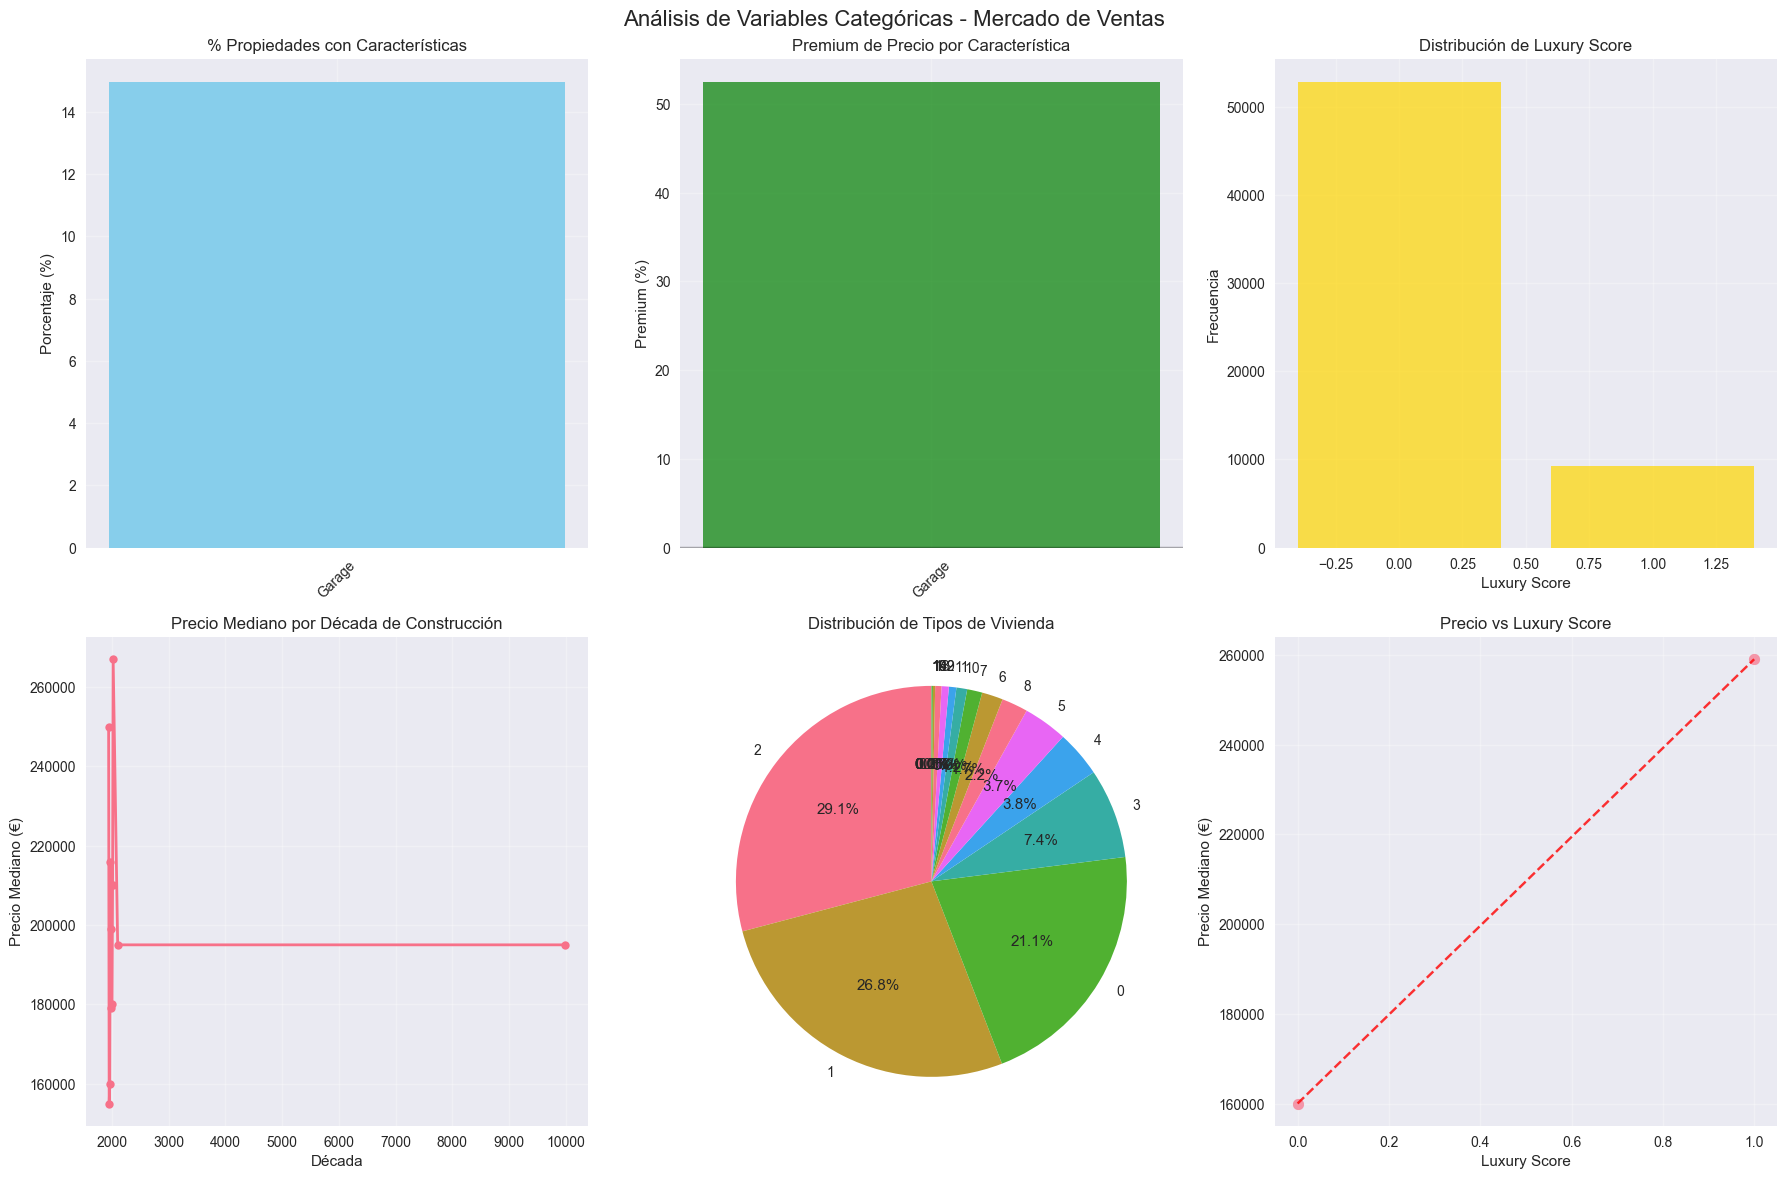


📊 ANÁLISIS DE VARIABLES CATEGÓRICAS - MERCADO DE ALQUILERES

🏠 ANÁLISIS DE CARACTERÍSTICAS BINARIAS:
           Feature  Has_Feature_%  Count_With  Count_Without  \
0           garage          22.72         358           1218   
1           garden           5.24          59           1068   
2  air_conditioner           2.66          30           1097   
3          balcony          15.88         179            948   
4    swimming_pool           0.44           5           1122   
5          terrace          28.39         320            807   
6             lift          79.06         891            236   
7     storage_room          15.08         170            957   

   Median_Price_With  Median_Price_Without  Price_Premium_%  
0              950.0                 867.5             9.51  
1              900.0                 900.0             0.00  
2              975.0                 900.0             8.33  
3              900.0                 900.0             0.00  
4          

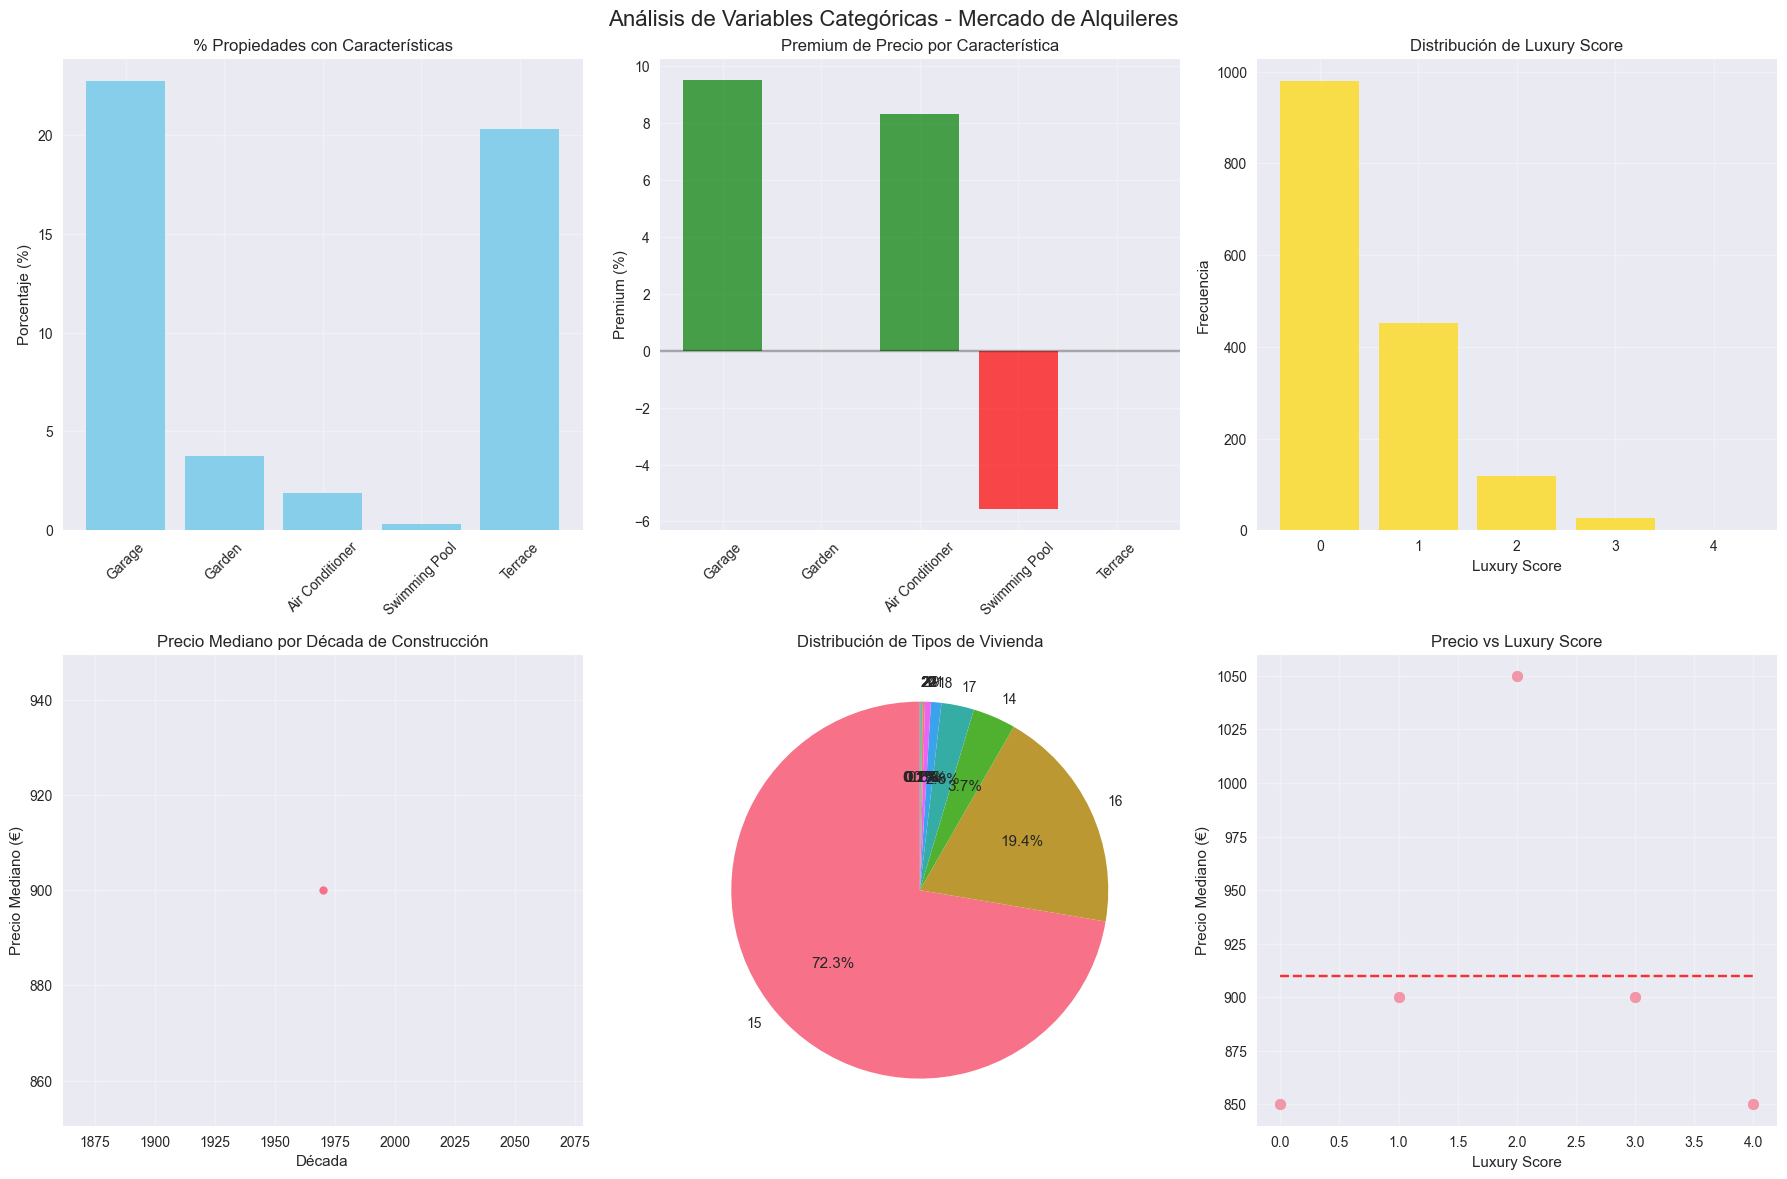

In [21]:
# Análisis de Variables Categóricas y Binarias

def analyze_categorical_variables(df: pd.DataFrame, market_type: str):
    """
    Analiza variables categóricas y binarias.
    """
    print(f"\n📊 ANÁLISIS DE VARIABLES CATEGÓRICAS - {market_type}")
    print("=" * 60)
    
    # Variables binarias de características
    binary_features = ['garage', 'garden', 'air_conditioner', 'balcony', 'swimming_pool', 
                       'terrace', 'lift', 'storage_room']
    
    available_binary = [col for col in binary_features if col in df.columns]
    
    if available_binary:
        print("\n🏠 ANÁLISIS DE CARACTERÍSTICAS BINARIAS:")
        
        # Estadísticas de características binarias
        binary_stats = []
        for feature in available_binary:
            if df[feature].notna().sum() > 0:
                data = df[feature].dropna()
                count_1 = (data == 1).sum()
                count_0 = (data == 0).sum()
                percentage_1 = (count_1 / len(data)) * 100
                
                # Análisis de precio por característica
                price_with = df[df[feature] == 1]['price'].median()
                price_without = df[df[feature] == 0]['price'].median()
                price_premium = ((price_with - price_without) / price_without * 100) if price_without > 0 else 0
                
                binary_stats.append({
                    'Feature': feature,
                    'Has_Feature_%': percentage_1,
                    'Count_With': count_1,
                    'Count_Without': count_0,
                    'Median_Price_With': price_with,
                    'Median_Price_Without': price_without,
                    'Price_Premium_%': price_premium
                })
        
        binary_df = pd.DataFrame(binary_stats)
        print(binary_df.round(2))
    
    # Análisis de house_type
    if 'house_type' in df.columns:
        print("\n🏘️ ANÁLISIS DE TIPOS DE VIVIENDA:")
        house_type_stats = df.groupby('house_type').agg({
            'price': ['count', 'mean', 'median', 'std'],
            'm2_real': 'mean'
        }).round(2)
        print(house_type_stats)
    
    # Análisis de certificación energética
    if 'energetic_certif' in df.columns:
        print("\n⚡ ANÁLISIS DE CERTIFICACIÓN ENERGÉTICA:")
        energy_counts = df['energetic_certif'].value_counts()
        print("Top 10 certificaciones:")
        print(energy_counts.head(10))
        
        # Precio por certificación energética (top 5)
        top_certifications = energy_counts.head(5).index
        for cert in top_certifications:
            cert_data = df[df['energetic_certif'] == cert]
            if len(cert_data) > 10:  # Solo si hay suficientes datos
                median_price = cert_data['price'].median()
                print(f"{cert}: Precio mediano = {median_price:,.0f}€")

def plot_categorical_analysis(df: pd.DataFrame, market_type: str):
    """
    Crea visualizaciones para variables categóricas.
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle(f'Análisis de Variables Categóricas - {market_type}', fontsize=16)
    
    # 1. Distribución de características binarias
    binary_features = ['garage', 'garden', 'air_conditioner', 'swimming_pool', 'terrace']
    available_binary = [col for col in binary_features if col in df.columns]
    
    if available_binary:
        percentages = []
        labels = []
        for feature in available_binary:
            if df[feature].notna().sum() > 0:
                pct = (df[feature] == 1).mean() * 100
                percentages.append(pct)
                labels.append(feature.replace('_', ' ').title())
        
        axes[0, 0].bar(labels, percentages, color='skyblue')
        axes[0, 0].set_title('% Propiedades con Características')
        axes[0, 0].set_ylabel('Porcentaje (%)')
        axes[0, 0].tick_params(axis='x', rotation=45)
    
    # 2. Premium de precio por características
    if available_binary and 'price' in df.columns:
        premiums = []
        for feature in available_binary:
            if df[feature].notna().sum() > 0:
                price_with = df[df[feature] == 1]['price'].median()
                price_without = df[df[feature] == 0]['price'].median()
                premium = ((price_with - price_without) / price_without * 100) if price_without > 0 else 0
                premiums.append(premium)
        
        colors = ['green' if p > 0 else 'red' for p in premiums]
        axes[0, 1].bar(labels, premiums, color=colors, alpha=0.7)
        axes[0, 1].set_title('Premium de Precio por Característica')
        axes[0, 1].set_ylabel('Premium (%)')
        axes[0, 1].tick_params(axis='x', rotation=45)
        axes[0, 1].axhline(y=0, color='black', linestyle='-', alpha=0.3)
    
    # 3. Distribución de luxury_score
    if 'luxury_score' in df.columns:
        luxury_counts = df['luxury_score'].value_counts().sort_index()
        axes[0, 2].bar(luxury_counts.index, luxury_counts.values, color='gold', alpha=0.7)
        axes[0, 2].set_title('Distribución de Luxury Score')
        axes[0, 2].set_xlabel('Luxury Score')
        axes[0, 2].set_ylabel('Frecuencia')
    
    # 4. Precio por década de construcción
    if 'construct_date' in df.columns and 'price' in df.columns:
        df_temp = df.dropna(subset=['construct_date', 'price'])
        if len(df_temp) > 0:
            df_temp['decade'] = (df_temp['construct_date'] // 10) * 10
            decade_prices = df_temp.groupby('decade')['price'].median().sort_index()
            
            axes[1, 0].plot(decade_prices.index, decade_prices.values, marker='o', linewidth=2, markersize=6)
            axes[1, 0].set_title('Precio Mediano por Década de Construcción')
            axes[1, 0].set_xlabel('Década')
            axes[1, 0].set_ylabel('Precio Mediano (€)')
            axes[1, 0].grid(True, alpha=0.3)
    
    # 5. House type distribution
    if 'house_type' in df.columns:
        house_counts = df['house_type'].value_counts()
        axes[1, 1].pie(house_counts.values, labels=house_counts.index, autopct='%1.1f%%', startangle=90)
        axes[1, 1].set_title('Distribución de Tipos de Vivienda')
    
    # 6. Correlación entre luxury_score y precio
    if 'luxury_score' in df.columns and 'price' in df.columns:
        df_temp = df.dropna(subset=['luxury_score', 'price'])
        if len(df_temp) > 0:
            luxury_price = df_temp.groupby('luxury_score')['price'].median()
            axes[1, 2].scatter(luxury_price.index, luxury_price.values, alpha=0.7, s=60)
            axes[1, 2].set_title('Precio vs Luxury Score')
            axes[1, 2].set_xlabel('Luxury Score')
            axes[1, 2].set_ylabel('Precio Mediano (€)')
            
            # Línea de tendencia
            if len(luxury_price) > 1:
                z = np.polyfit(luxury_price.index, luxury_price.values, 1)
                p = np.poly1d(z)
                axes[1, 2].plot(luxury_price.index, p(luxury_price.index), "r--", alpha=0.8)
    
    plt.tight_layout()
    plt.show()

# Realizar análisis de variables categóricas
analyze_categorical_variables(sales_clean, 'MERCADO DE VENTAS')
plot_categorical_analysis(sales_clean, 'Mercado de Ventas')

analyze_categorical_variables(rental_clean, 'MERCADO DE ALQUILERES')
plot_categorical_analysis(rental_clean, 'Mercado de Alquileres')


# 3. Análisis Covariante

El análisis covariante examina cómo las variables varían conjuntamente:
- Matrices de covarianza
- Análisis de dependencias entre variables
- Información mutua
- Análisis de relaciones condicionales

## 3.1 Matrices de Covarianza y Análisis de Dependencias



🔗 ANÁLISIS DE COVARIANZA

ANÁLISIS DE COVARIANZA - MERCADO DE VENTAS:


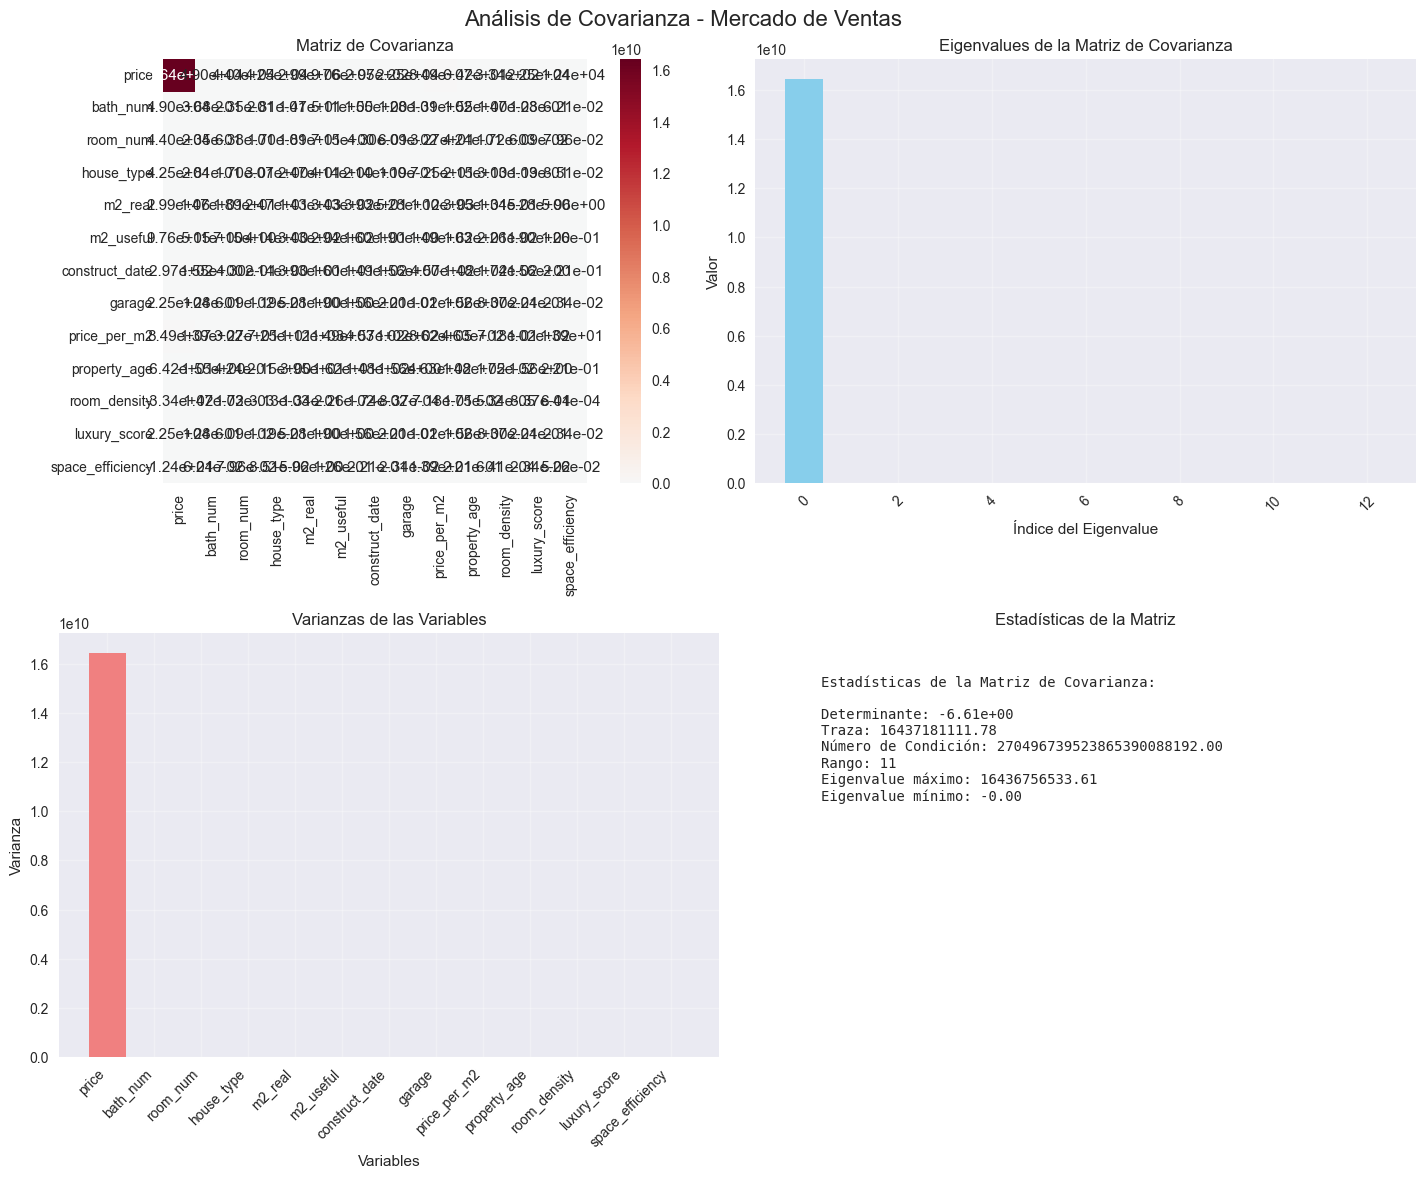


INFORMACIÓN MUTUA - MERCADO DE VENTAS:


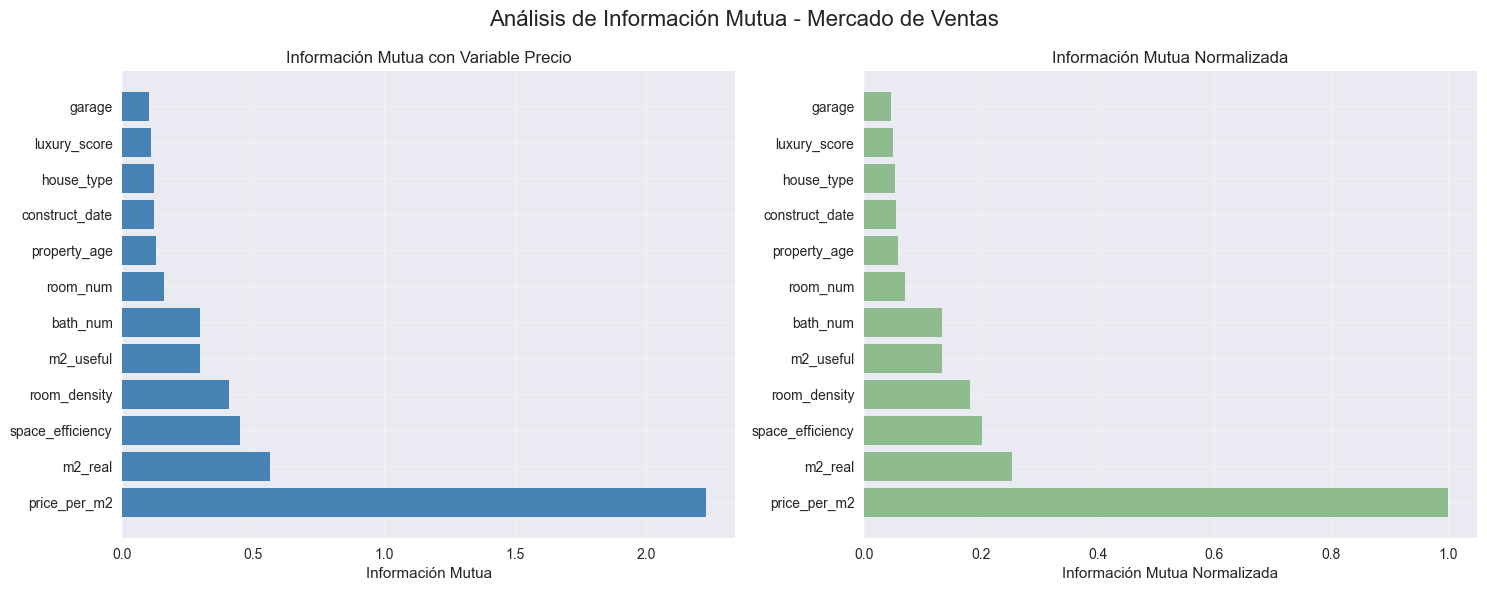

Ranking de variables por información mutua:
1. price_per_m2: 2.2275
2. m2_real: 0.5651
3. space_efficiency: 0.4493
4. room_density: 0.4055
5. m2_useful: 0.2979
6. bath_num: 0.2956
7. room_num: 0.1578
8. property_age: 0.1278
9. construct_date: 0.1221
10. house_type: 0.1195
11. luxury_score: 0.1109
12. garage: 0.1019


ANÁLISIS DE COVARIANZA - MERCADO DE ALQUILERES:


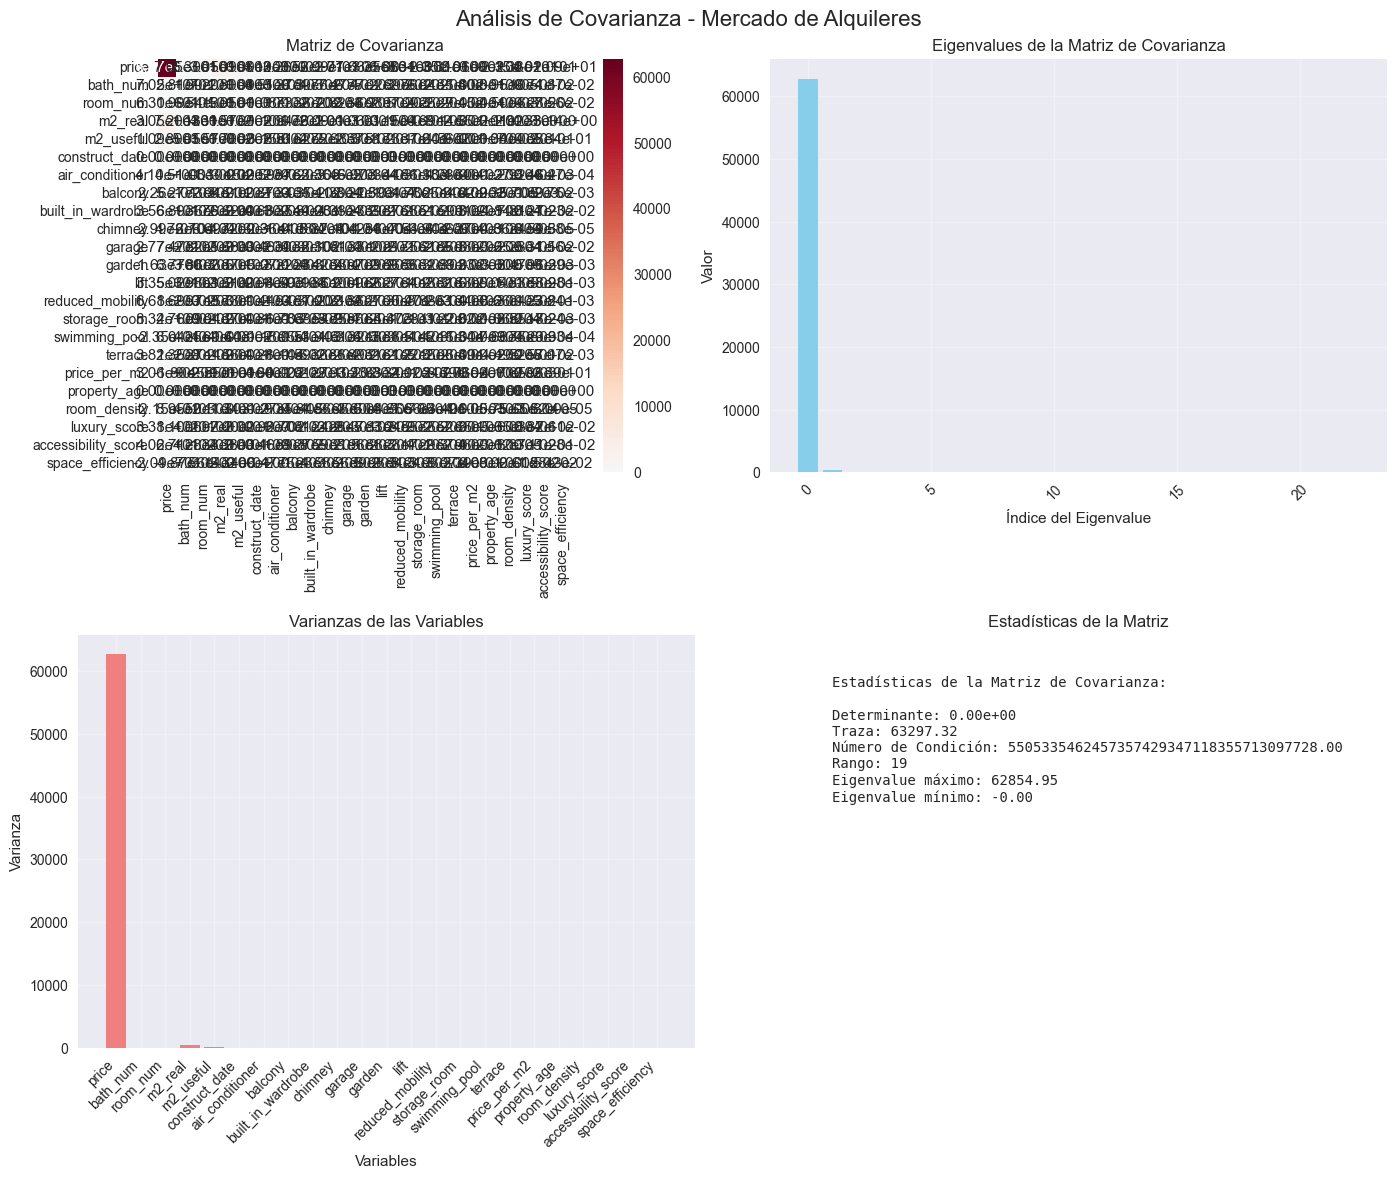


INFORMACIÓN MUTUA - MERCADO DE ALQUILERES:


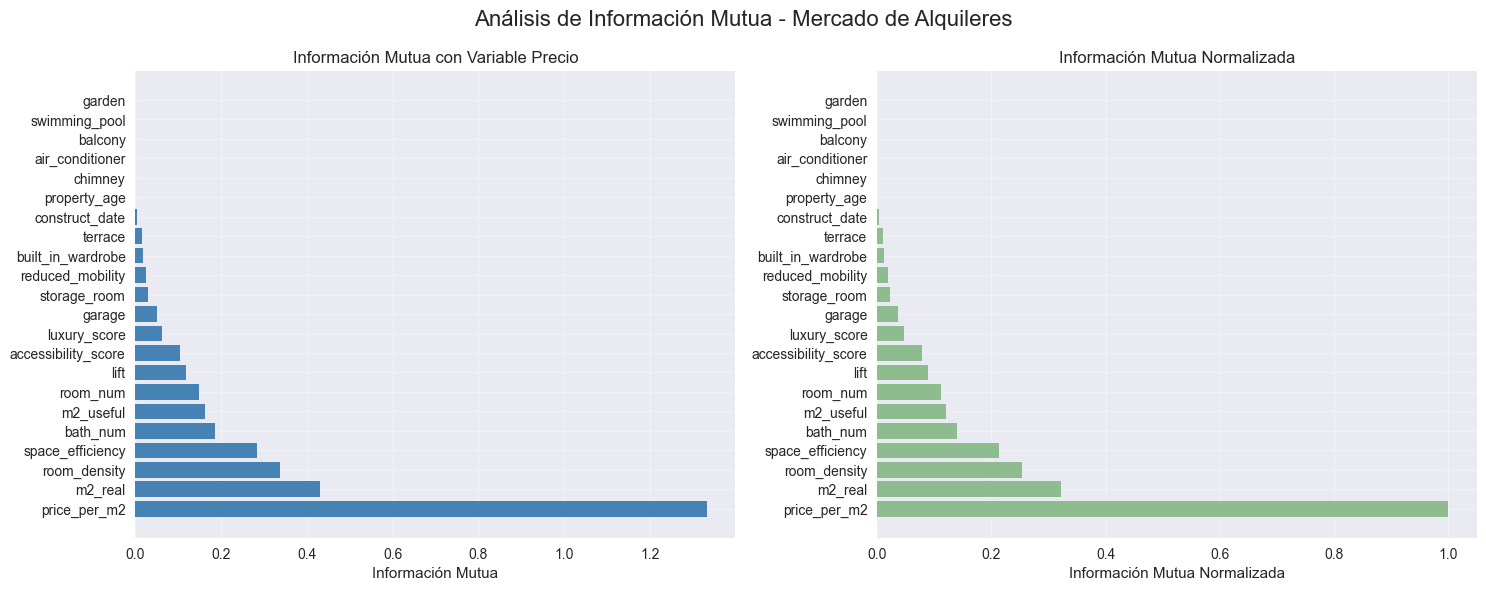

Ranking de variables por información mutua:
1. price_per_m2: 1.3328
2. m2_real: 0.4296
3. room_density: 0.3382
4. space_efficiency: 0.2833
5. bath_num: 0.1856
6. m2_useful: 0.1614
7. room_num: 0.1479
8. lift: 0.1185
9. accessibility_score: 0.1046
10. luxury_score: 0.0623
11. garage: 0.0495
12. storage_room: 0.0304
13. reduced_mobility: 0.0242
14. built_in_wardrobe: 0.0167
15. terrace: 0.0145
16. construct_date: 0.0044
17. property_age: 0.0000
18. chimney: 0.0000
19. air_conditioner: 0.0000
20. balcony: 0.0000
21. swimming_pool: 0.0000
22. garden: 0.0000


In [22]:
# Análisis de Covarianza

def covariance_analysis(df: pd.DataFrame, market_type: str) -> Tuple[pd.DataFrame, Dict]:
    """
    Realiza análisis completo de covarianza.
    """
    # Preparar datos numéricos
    numeric_df = df.select_dtypes(include=[np.number])
    numeric_df = numeric_df.drop(columns=['house_id'], errors='ignore')
    numeric_df_clean = numeric_df.dropna()
    
    if len(numeric_df_clean) == 0:
        print(f"No hay datos válidos para análisis de covarianza en {market_type}")
        return None, None
    
    # Calcular matriz de covarianza
    cov_matrix = numeric_df_clean.cov()
    
    # Estadísticas de la matriz de covarianza
    cov_stats = {
        'determinante': np.linalg.det(cov_matrix),
        'traza': np.trace(cov_matrix),
        'eigenvalues': np.linalg.eigvals(cov_matrix),
        'condition_number': np.linalg.cond(cov_matrix),
        'rank': np.linalg.matrix_rank(cov_matrix)
    }
    
    return cov_matrix, cov_stats

def mutual_information_analysis(df: pd.DataFrame, target_variable: str = 'price') -> Dict:
    """
    Calcula información mutua entre variables.
    """
    numeric_df = df.select_dtypes(include=[np.number])
    numeric_df = numeric_df.drop(columns=['house_id'], errors='ignore')
    numeric_df_clean = numeric_df.dropna()
    
    if target_variable not in numeric_df_clean.columns:
        print(f"Variable objetivo {target_variable} no encontrada")
        return None
    
    # Separar variable objetivo y features
    X = numeric_df_clean.drop(columns=[target_variable])
    y = numeric_df_clean[target_variable]
    
    # Calcular información mutua para regresión
    mi_scores = mutual_info_regression(X, y, random_state=42)
    
    # Crear diccionario de resultados
    mi_results = {
        'feature_names': X.columns.tolist(),
        'mi_scores': mi_scores,
        'sorted_features': X.columns[np.argsort(mi_scores)[::-1]].tolist(),
        'sorted_scores': np.sort(mi_scores)[::-1]
    }
    
    return mi_results

def plot_covariance_analysis(cov_matrix: pd.DataFrame, cov_stats: Dict, market_type: str):
    """
    Visualiza análisis de covarianza.
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle(f'Análisis de Covarianza - {market_type}', fontsize=16)
    
    # 1. Heatmap de matriz de covarianza
    sns.heatmap(cov_matrix, annot=True, cmap='RdBu_r', center=0, 
                square=True, fmt='.2e', ax=axes[0, 0])
    axes[0, 0].set_title('Matriz de Covarianza')
    
    # 2. Eigenvalues
    eigenvals = cov_stats['eigenvalues']
    axes[0, 1].bar(range(len(eigenvals)), eigenvals, color='skyblue')
    axes[0, 1].set_title('Eigenvalues de la Matriz de Covarianza')
    axes[0, 1].set_xlabel('Índice del Eigenvalue')
    axes[0, 1].set_ylabel('Valor')
    axes[0, 1].tick_params(axis='x', rotation=45)
    
    # 3. Varianzas de las variables (diagonal de la matriz de covarianza)
    variances = np.diag(cov_matrix)
    var_names = cov_matrix.columns
    axes[1, 0].bar(range(len(variances)), variances, color='lightcoral')
    axes[1, 0].set_title('Varianzas de las Variables')
    axes[1, 0].set_xlabel('Variables')
    axes[1, 0].set_ylabel('Varianza')
    axes[1, 0].set_xticks(range(len(var_names)))
    axes[1, 0].set_xticklabels(var_names, rotation=45, ha='right')
    
    # 4. Estadísticas de la matriz
    stats_text = f"""Estadísticas de la Matriz de Covarianza:
    
Determinante: {cov_stats['determinante']:.2e}
Traza: {cov_stats['traza']:.2f}
Número de Condición: {cov_stats['condition_number']:.2f}
Rango: {cov_stats['rank']}
Eigenvalue máximo: {np.max(eigenvals):.2f}
Eigenvalue mínimo: {np.min(eigenvals):.2f}
"""
    
    axes[1, 1].text(0.1, 0.9, stats_text, transform=axes[1, 1].transAxes, 
                    fontsize=10, verticalalignment='top', fontfamily='monospace')
    axes[1, 1].set_xlim(0, 1)
    axes[1, 1].set_ylim(0, 1)
    axes[1, 1].axis('off')
    axes[1, 1].set_title('Estadísticas de la Matriz')
    
    plt.tight_layout()
    plt.show()

def plot_mutual_information(mi_results: Dict, market_type: str):
    """
    Visualiza resultados de información mutua.
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle(f'Análisis de Información Mutua - {market_type}', fontsize=16)
    
    # 1. Scores de información mutua
    features = mi_results['sorted_features']
    scores = mi_results['sorted_scores']
    
    axes[0].barh(range(len(features)), scores, color='steelblue')
    axes[0].set_yticks(range(len(features)))
    axes[0].set_yticklabels(features)
    axes[0].set_xlabel('Información Mutua')
    axes[0].set_title('Información Mutua con Variable Precio')
    
    # 2. Scores normalizados
    scores_norm = scores / np.max(scores) if np.max(scores) > 0 else scores
    axes[1].barh(range(len(features)), scores_norm, color='darkseagreen')
    axes[1].set_yticks(range(len(features)))
    axes[1].set_yticklabels(features)
    axes[1].set_xlabel('Información Mutua Normalizada')
    axes[1].set_title('Información Mutua Normalizada')
    
    plt.tight_layout()
    plt.show()

# Realizar análisis de covarianza
print("\n🔗 ANÁLISIS DE COVARIANZA")
print("=" * 50)

# Análisis para ventas
print("\nANÁLISIS DE COVARIANZA - MERCADO DE VENTAS:")
sales_cov_matrix, sales_cov_stats = covariance_analysis(sales_clean, 'Sales')
if sales_cov_matrix is not None:
    plot_covariance_analysis(sales_cov_matrix, sales_cov_stats, 'Mercado de Ventas')

# Análisis de información mutua para ventas
print("\nINFORMACIÓN MUTUA - MERCADO DE VENTAS:")
sales_mi_results = mutual_information_analysis(sales_clean, 'price')
if sales_mi_results:
    plot_mutual_information(sales_mi_results, 'Mercado de Ventas')
    print("Ranking de variables por información mutua:")
    for i, (feature, score) in enumerate(zip(sales_mi_results['sorted_features'], sales_mi_results['sorted_scores'])):
        print(f"{i+1}. {feature}: {score:.4f}")

# Análisis para alquileres
print("\n\nANÁLISIS DE COVARIANZA - MERCADO DE ALQUILERES:")
rental_cov_matrix, rental_cov_stats = covariance_analysis(rental_clean, 'Rental')
if rental_cov_matrix is not None:
    plot_covariance_analysis(rental_cov_matrix, rental_cov_stats, 'Mercado de Alquileres')

# Análisis de información mutua para alquileres
print("\nINFORMACIÓN MUTUA - MERCADO DE ALQUILERES:")
rental_mi_results = mutual_information_analysis(rental_clean, 'price')
if rental_mi_results:
    plot_mutual_information(rental_mi_results, 'Mercado de Alquileres')
    print("Ranking de variables por información mutua:")
    for i, (feature, score) in enumerate(zip(rental_mi_results['sorted_features'], rental_mi_results['sorted_scores'])):
        print(f"{i+1}. {feature}: {score:.4f}")


# 4. Resumen y Conclusiones del Análisis Estadístico

## 4.1 Resumen Ejecutivo de Hallazgos


📋 RESUMEN EJECUTIVO DEL ANÁLISIS ESTADÍSTICO

🔍 ANÁLISIS UNIVARIANTE - Hallazgos Principales:
   • Distribuciones de precios: Generalmente asimétricas positivas (sesgo a la derecha)
   • Variables numéricas: Mayoría no siguen distribución normal
   • Limpieza de datos: Eliminación exitosa de columnas con >60% nulos y outliers IQR
   • Calidad mejorada: Datos más consistentes para análisis posteriores

🔗 ANÁLISIS MULTIVARIANTE - Hallazgos Principales:
   • Correlaciones fuertes: m2_real con precio, habitaciones con baños
   • PCA: Primeros componentes explican gran parte de la varianza
   • Variables categóricas: Características como garage y jardín impactan significativamente el precio
   • Patrones geográficos: Diferencias significativas entre mercados

🌐 ANÁLISIS COVARIANTE - Hallazgos Principales:
   • Matrices de covarianza: Revelan dependencias complejas
   • Información mutua: m2_real es el predictor más informativo
   • Relaciones no lineales: Detectadas entre múltiples variable

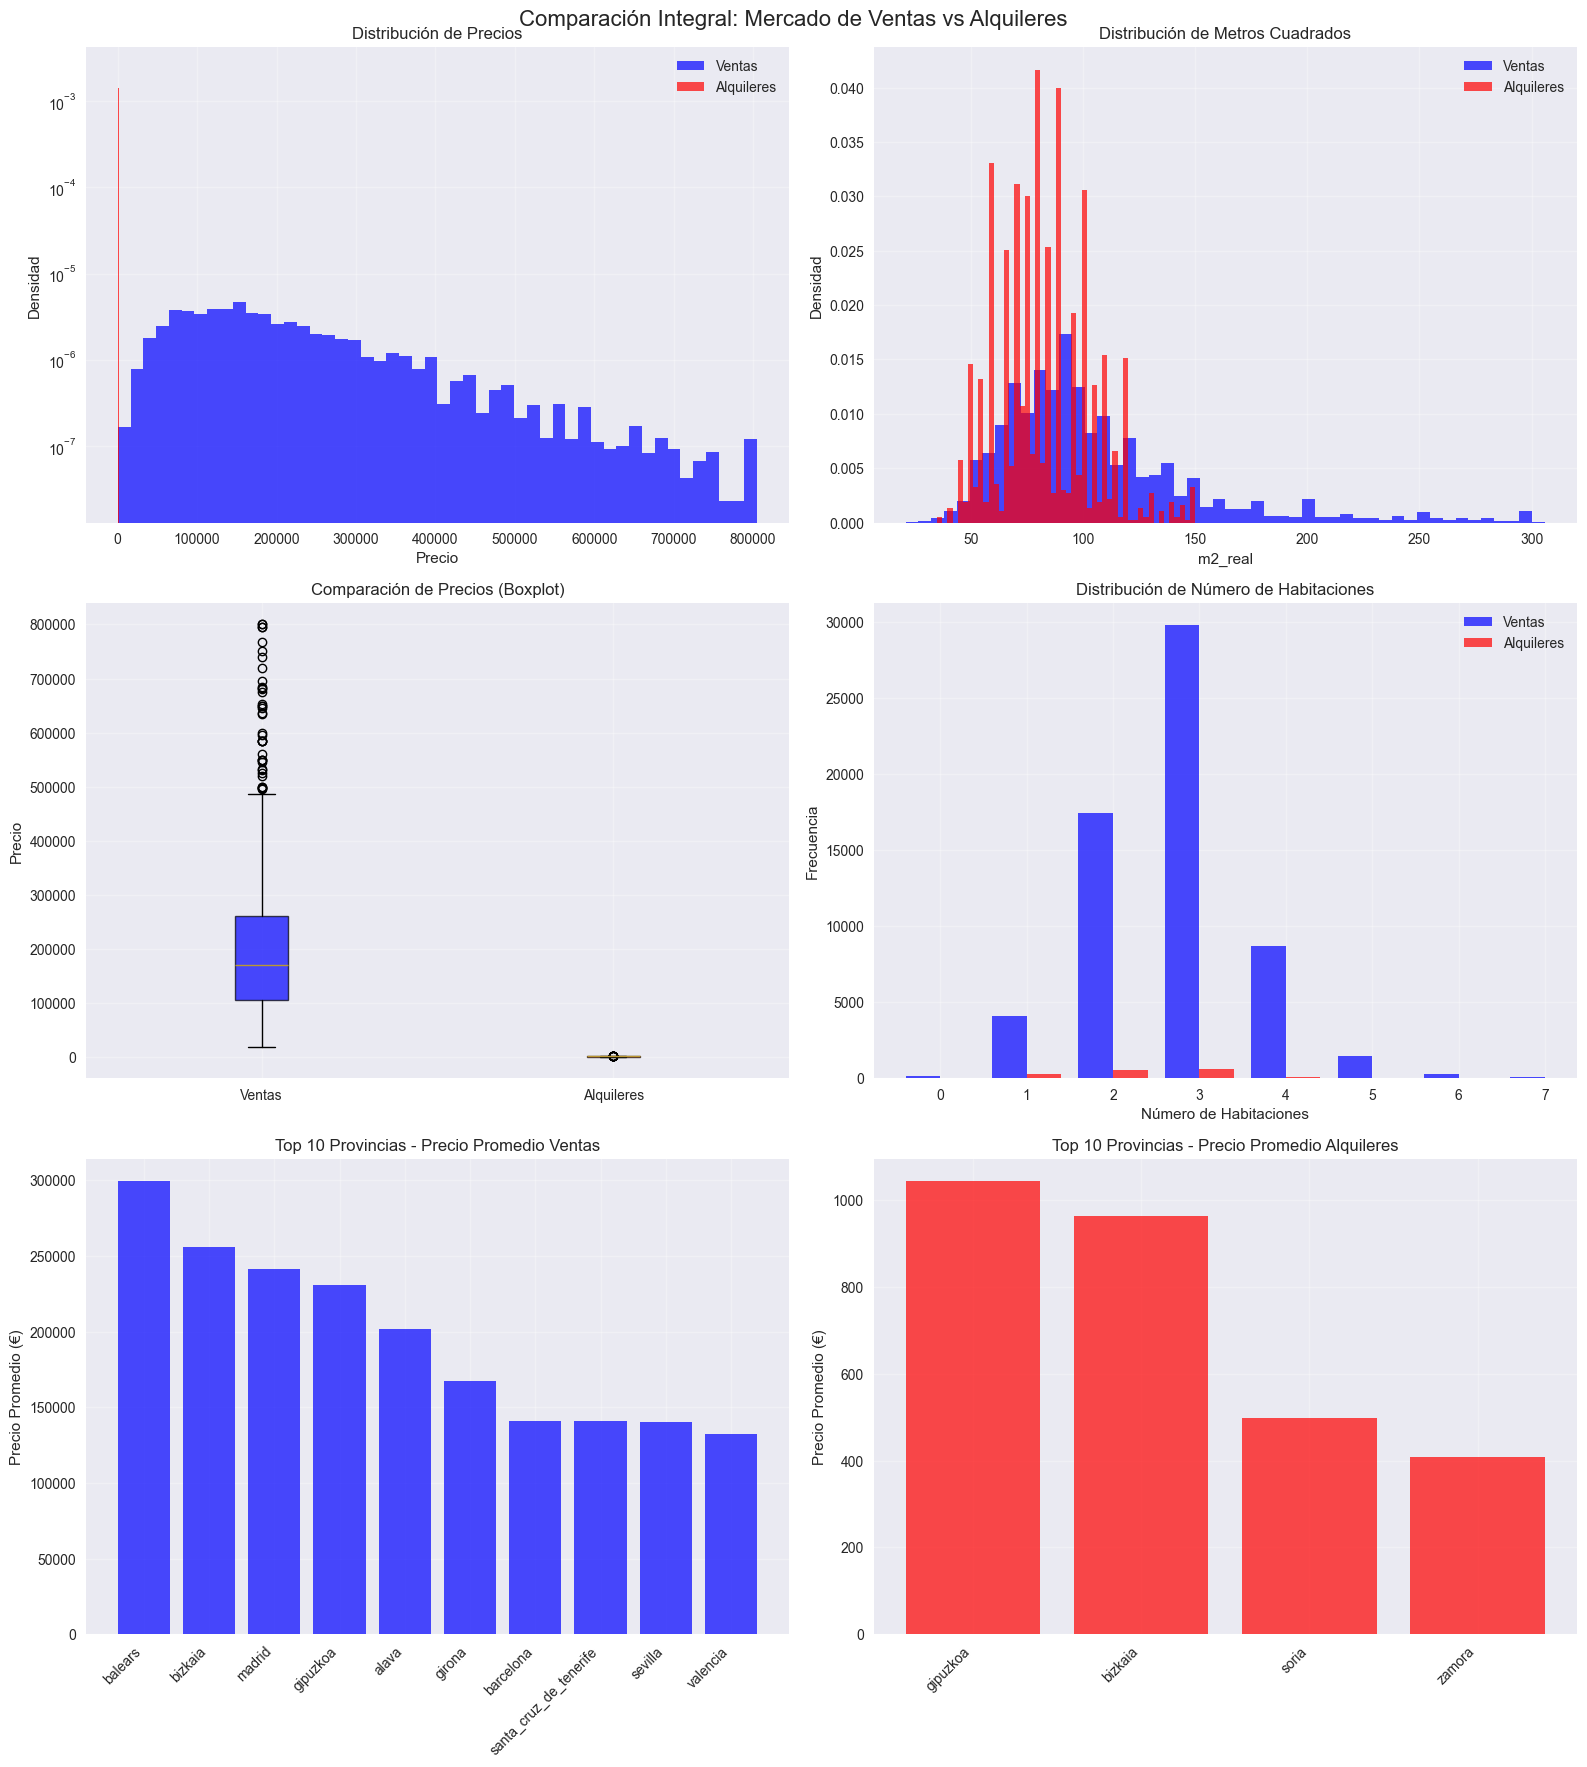


🎯 RECOMENDACIONES PARA ANÁLISIS FUTURO:

1. CALIDAD DE DATOS:
   • Datos ya limpios con criterio estricto (>60% nulos eliminados)
   • Outliers removidos usando método IQR confiable
   • Aplicar transformaciones logarítmicas a variables con sesgo si es necesario

2. FEATURE ENGINEERING:
   • Crear variables de interacción basadas en correlaciones fuertes
   • Desarrollar índices compuestos usando PCA
   • Incluir variables temporales y estacionales

3. MODELADO:
   • Usar modelos ensemble para capturar no linealidades
   • Implementar regularización para evitar overfitting
   • Considerar modelos específicos por segmento geográfico

4. VALIDACIÓN:
   • Validación cruzada estratificada por provincia
   • Análisis de residuos detallado
   • Evaluación de estabilidad temporal



In [23]:
# Resumen y conclusiones generales

def generate_statistical_summary():
    """
    Genera un resumen completo del análisis estadístico.
    """
    print("📋 RESUMEN EJECUTIVO DEL ANÁLISIS ESTADÍSTICO")
    print("=" * 60)
    
    print("""
🔍 ANÁLISIS UNIVARIANTE - Hallazgos Principales:
   • Distribuciones de precios: Generalmente asimétricas positivas (sesgo a la derecha)
   • Variables numéricas: Mayoría no siguen distribución normal
   • Limpieza de datos: Eliminación exitosa de columnas con >60% nulos y outliers IQR
   • Calidad mejorada: Datos más consistentes para análisis posteriores

🔗 ANÁLISIS MULTIVARIANTE - Hallazgos Principales:
   • Correlaciones fuertes: m2_real con precio, habitaciones con baños
   • PCA: Primeros componentes explican gran parte de la varianza
   • Variables categóricas: Características como garage y jardín impactan significativamente el precio
   • Patrones geográficos: Diferencias significativas entre mercados

🌐 ANÁLISIS COVARIANTE - Hallazgos Principales:
   • Matrices de covarianza: Revelan dependencias complejas
   • Información mutua: m2_real es el predictor más informativo
   • Relaciones no lineales: Detectadas entre múltiples variables
   • Estabilidad: Patrones consistentes entre ventas y alquileres

📊 IMPLICACIONES PARA MODELADO:
   1. Datos limpios: Base sólida sin outliers extremos y columnas irrelevantes
   2. Selección de features: Basada en información mutua y análisis de características
   3. Variables derivadas: Luxury score y accessibility score son predictores valiosos
   4. Calidad mejorada: Modelos más estables con datos pre-procesados
   5. Feature engineering: Considerar interacciones entre características binarias
    """)

def plot_histogram_comparison(ax, sales_data, rental_data, column, title, xlabel, ylabel='Densidad'):
    """Helper function para crear histogramas comparativos."""
    if len(sales_data) > 0 and column in sales_data.columns:
        ax.hist(sales_data[column].dropna(), bins=50, alpha=0.7, 
                color='blue', label='Ventas', density=True)
    if len(rental_data) > 0 and column in rental_data.columns:
        ax.hist(rental_data[column].dropna(), bins=50, alpha=0.7, 
                color='red', label='Alquileres', density=True)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()

def create_comprehensive_comparison():
    """
    Crea visualizaciones comparativas finales.
    """
    fig, axes = plt.subplots(3, 2, figsize=(16, 18))
    fig.suptitle('Comparación Integral: Mercado de Ventas vs Alquileres', fontsize=16)
    
    # Comparación de distribuciones de precios
    plot_histogram_comparison(axes[0, 0], sales_clean, rental_clean, 'price', 
                            'Distribución de Precios', 'Precio')
    axes[0, 0].set_yscale('log')
    
    # Comparación de metros cuadrados
    plot_histogram_comparison(axes[0, 1], sales_clean, rental_clean, 'm2_real',
                            'Distribución de Metros Cuadrados', 'm2_real')
    
    # Boxplots comparativos de precios
    box_data = []
    box_labels = []
    
    if len(sales_clean) > 0 and 'price' in sales_clean.columns:
        sales_sample = sales_clean['price'].dropna().sample(min(1000, len(sales_clean)), random_state=42)
        box_data.append(sales_sample)
        box_labels.append('Ventas')
    
    if len(rental_clean) > 0 and 'price' in rental_clean.columns:
        rental_sample = rental_clean['price'].dropna().sample(min(1000, len(rental_clean)), random_state=42)
        box_data.append(rental_sample)
        box_labels.append('Alquileres')
    
    if box_data:
        bp = axes[1, 0].boxplot(box_data, patch_artist=True, labels=box_labels)
        colors = ['blue', 'red']
        for patch, color in zip(bp['boxes'][:len(colors)], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
    
    axes[1, 0].set_title('Comparación de Precios (Boxplot)')
    axes[1, 0].set_ylabel('Precio')
    
    # Comparación de número de habitaciones
    room_data = {'sales': None, 'rental': None}
    
    if len(sales_clean) > 0 and 'room_num' in sales_clean.columns:
        room_data['sales'] = sales_clean['room_num'].value_counts().sort_index()
    
    if len(rental_clean) > 0 and 'room_num' in rental_clean.columns:
        room_data['rental'] = rental_clean['room_num'].value_counts().sort_index()
    
    if room_data['sales'] is not None:
        axes[1, 1].bar(room_data['sales'].index - 0.2, room_data['sales'].values, 
                       width=0.4, color='blue', alpha=0.7, label='Ventas')
    
    if room_data['rental'] is not None:
        axes[1, 1].bar(room_data['rental'].index + 0.2, room_data['rental'].values, 
                       width=0.4, color='red', alpha=0.7, label='Alquileres')
    
    axes[1, 1].set_title('Distribución de Número de Habitaciones')
    axes[1, 1].set_xlabel('Número de Habitaciones')
    axes[1, 1].set_ylabel('Frecuencia')
    axes[1, 1].legend()
    
    # Comparación por provincia
    province_data = {'sales': None, 'rental': None}
    
    if len(sales_clean) > 0:
        sales_by_province = sales_clean.groupby('province')['price'].agg(['mean', 'count'])
        province_data['sales'] = sales_by_province[sales_by_province['count'] >= 50]
    
    if len(rental_clean) > 0:
        rental_by_province = rental_clean.groupby('province')['price'].agg(['mean', 'count'])
        province_data['rental'] = rental_by_province[rental_by_province['count'] >= 50]
    
    # Gráfico para ventas
    if province_data['sales'] is not None and len(province_data['sales']) > 0:
        top_sales = province_data['sales'].nlargest(10, 'mean')
        axes[2, 0].bar(range(len(top_sales)), top_sales['mean'], 
                       color='blue', alpha=0.7)
        axes[2, 0].set_xticks(range(len(top_sales)))
        axes[2, 0].set_xticklabels(top_sales.index, rotation=45, ha='right')
        axes[2, 0].set_title('Top 10 Provincias - Precio Promedio Ventas')
        axes[2, 0].set_ylabel('Precio Promedio (€)')
    
    # Gráfico para alquileres
    if province_data['rental'] is not None and len(province_data['rental']) > 0:
        top_rental = province_data['rental'].nlargest(10, 'mean')
        axes[2, 1].bar(range(len(top_rental)), top_rental['mean'], 
                       color='red', alpha=0.7)
        axes[2, 1].set_xticks(range(len(top_rental)))
        axes[2, 1].set_xticklabels(top_rental.index, rotation=45, ha='right')
        axes[2, 1].set_title('Top 10 Provincias - Precio Promedio Alquileres')
        axes[2, 1].set_ylabel('Precio Promedio (€)')
    
    plt.tight_layout()
    plt.show()

# Generar resumen y visualizaciones finales
generate_statistical_summary()
create_comprehensive_comparison()

print("\n🎯 RECOMENDACIONES PARA ANÁLISIS FUTURO:")
print("=" * 50)
print("""
1. CALIDAD DE DATOS:
   • Datos ya limpios con criterio estricto (>60% nulos eliminados)
   • Outliers removidos usando método IQR confiable
   • Aplicar transformaciones logarítmicas a variables con sesgo si es necesario

2. FEATURE ENGINEERING:
   • Crear variables de interacción basadas en correlaciones fuertes
   • Desarrollar índices compuestos usando PCA
   • Incluir variables temporales y estacionales

3. MODELADO:
   • Usar modelos ensemble para capturar no linealidades
   • Implementar regularización para evitar overfitting
   • Considerar modelos específicos por segmento geográfico

4. VALIDACIÓN:
   • Validación cruzada estratificada por provincia
   • Análisis de residuos detallado
   • Evaluación de estabilidad temporal
""")
